In [74]:
import mplhep
mplhep.style.use('ROOT')
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import hist
import uproot

class HistFile:
    def __init__(self, fp, ana, **kwargs):
        self._file = uproot.open(fp, **kwargs)
        self._ana = ana
        self._ana_dir = self._file[self._ana]

    def keys(self):
        return [
            key.removeprefix(f'{self._ana}_').removesuffix(';1')
            for key in self._ana_dir.keys()
        ]

    def __getitem__(self, item):
        if item in self._ana_dir:
            return self._ana_dir[item]
        if item in self._file:
            return self._file[item]
        return self._ana_dir[f'{self._ana}_{item}']

In [75]:
f = HistFile('hist_track_ana_1.root', 'TrackAnalyzer')

In [76]:
f.keys()

['event_tracks',
 'n_hits',
 'clean_event_tracks',
 'impact_point',
 'leadtrk_impact_point',
 'reco_momentum',
 'sim_momentum',
 'reco_leadtrk_momentum',
 'reco_leadtrk_momentum_neg_charge',
 'reco_leadtrk_momentum_impact_cuts',
 'leadtrk_reco_vs_sim_momentum',
 'leadtrk_reco_vs_sim_momentum_impact_cuts',
 'leadtrk_reco_vs_sim_momentum_nhits_10_impact_cuts',
 'leadtrk_reco_vs_sim_momentum_nhits_10',
 'leadtrk_chi2',
 'leadtrk_chi2_nhits_10',
 'leadtrk_chi2_nhits_10_impact_cuts',
 'leadtrk_all_req_reduced_chi2',
 'energy_diff_vs_chi2',
 'difference',
 'EScorePlane_momentum',
 'leading_electron_energy',
 'leading_E_vs_lead_E_w_energy_nearby_R2',
 'leadtrk_reco_vs_Lead_E_w_nearby_R2',
 'leadtrk_reco_nhits_10_vs_Lead_E_w_nearby_R2',
 'leadtrk_reco_nhits_10_impact_cuts_vs_Energy_Estimate_R2']

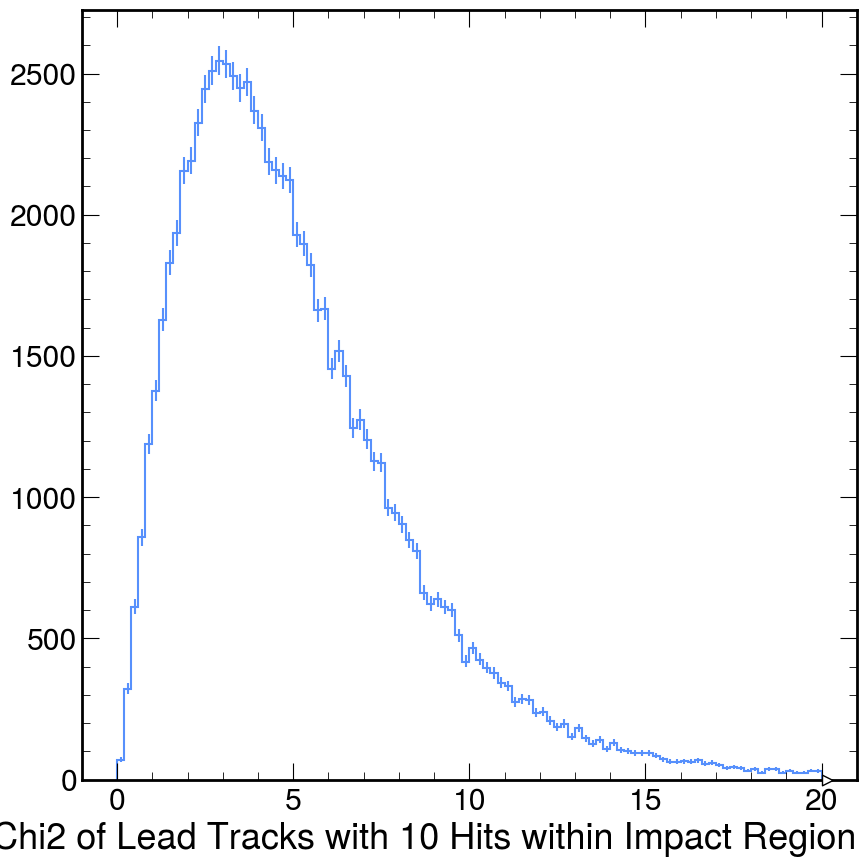

In [94]:
f['leadtrk_chi2_nhits_10_impact_cuts'].to_hist().plot()
#plt.yscale('log')
#plt.ylim(0,8)

plt.savefig("chi2_all_reqs.jpg")
plt.show()

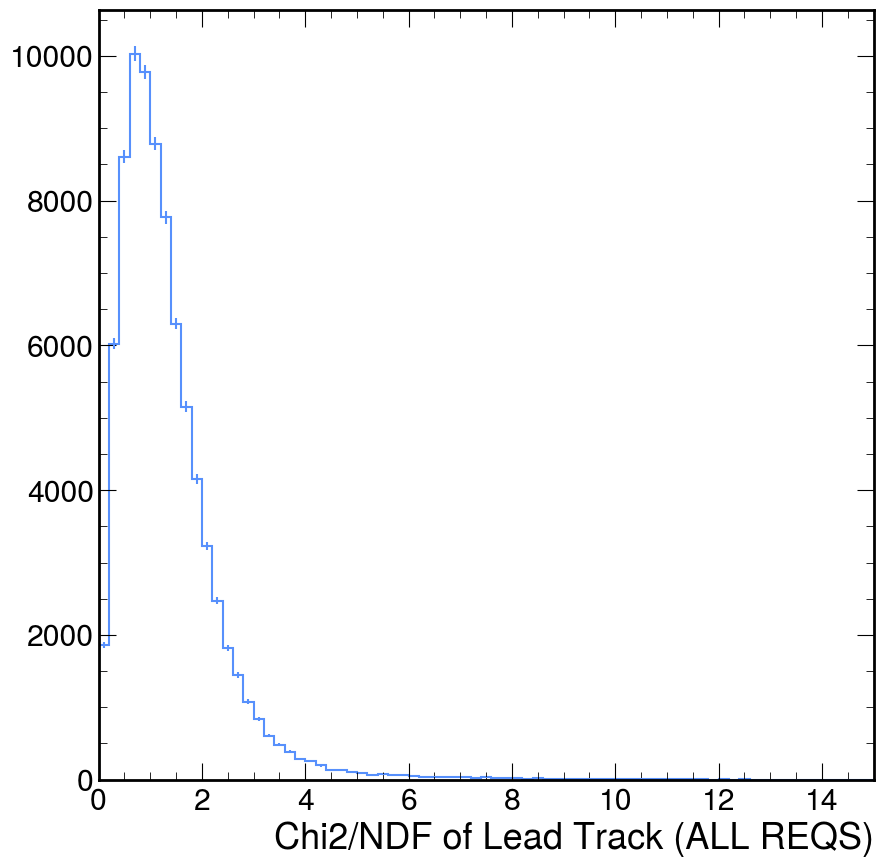

In [95]:
f['leadtrk_all_req_reduced_chi2'].to_hist().plot()
plt.xlim(0,15)
plt.savefig("reduced_chi2_all_reqs.jpg")
plt.show()

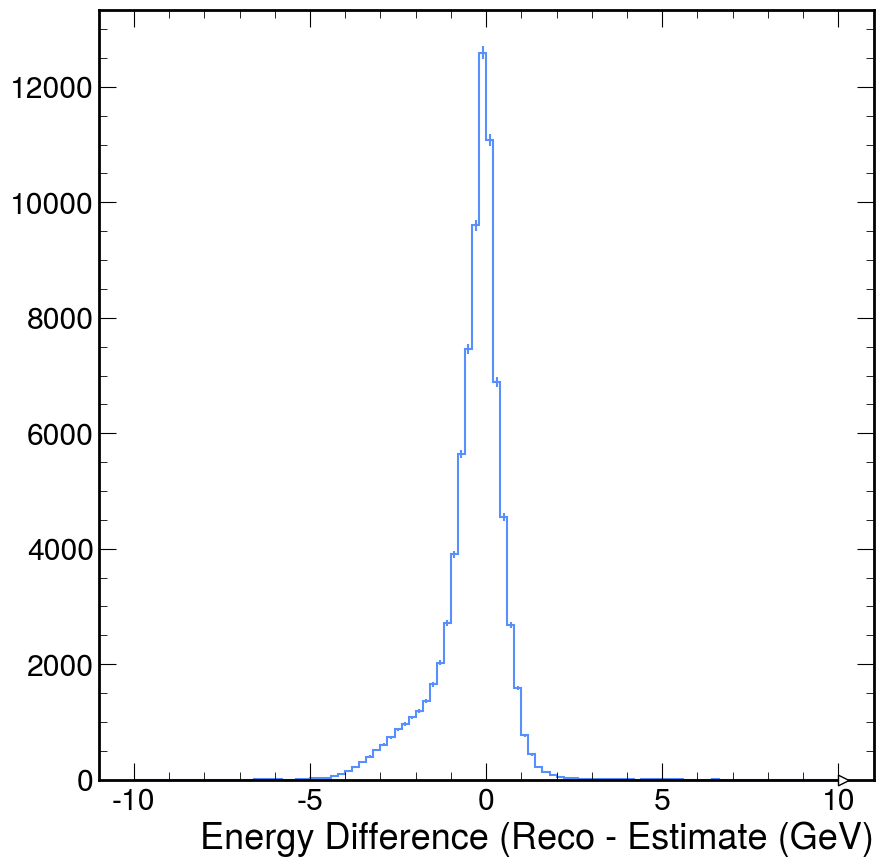

In [96]:
f['difference'].to_hist().plot()
#plt.yscale('log')
#plt.ylim(0,8)
plt.savefig("energy_difference.jpg")
plt.show()

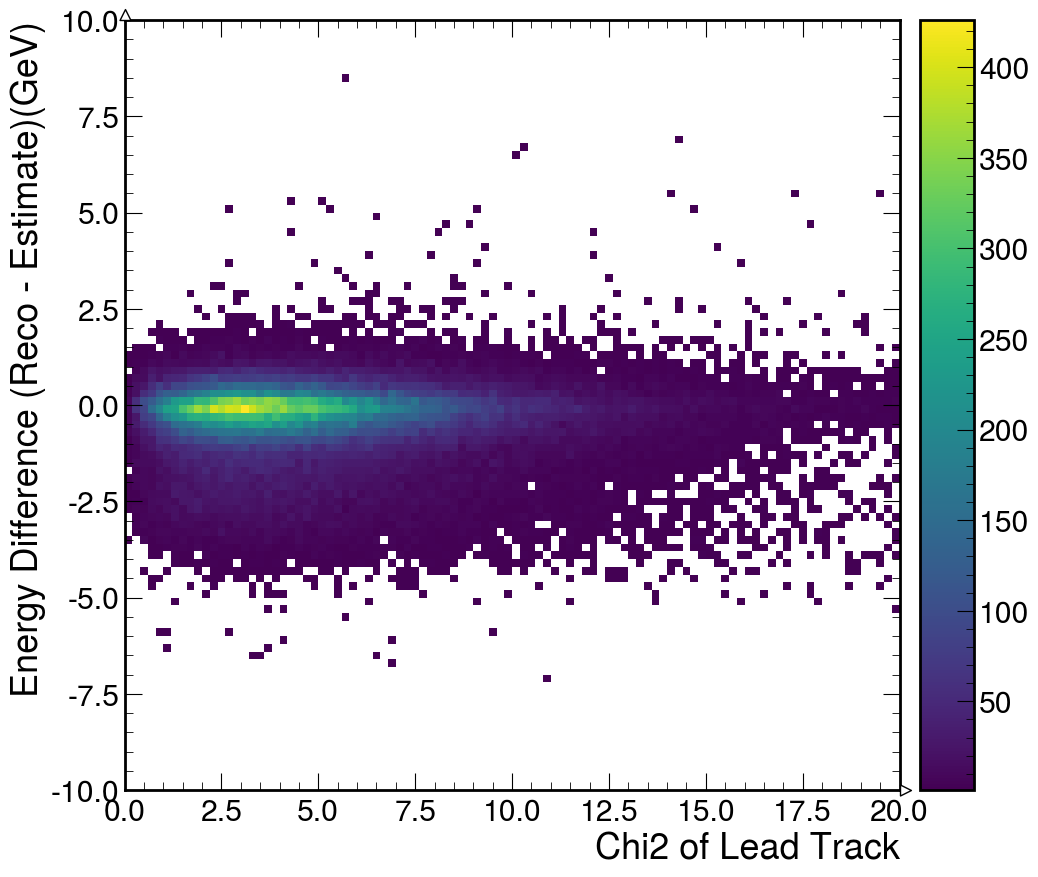

In [97]:
f['energy_diff_vs_chi2'].to_hist().plot(cmin=1)
#plt.yscale('log')
#plt.ylim(0,8)
plt.savefig("energy_diff_vs_chi2.jpg")
plt.show()

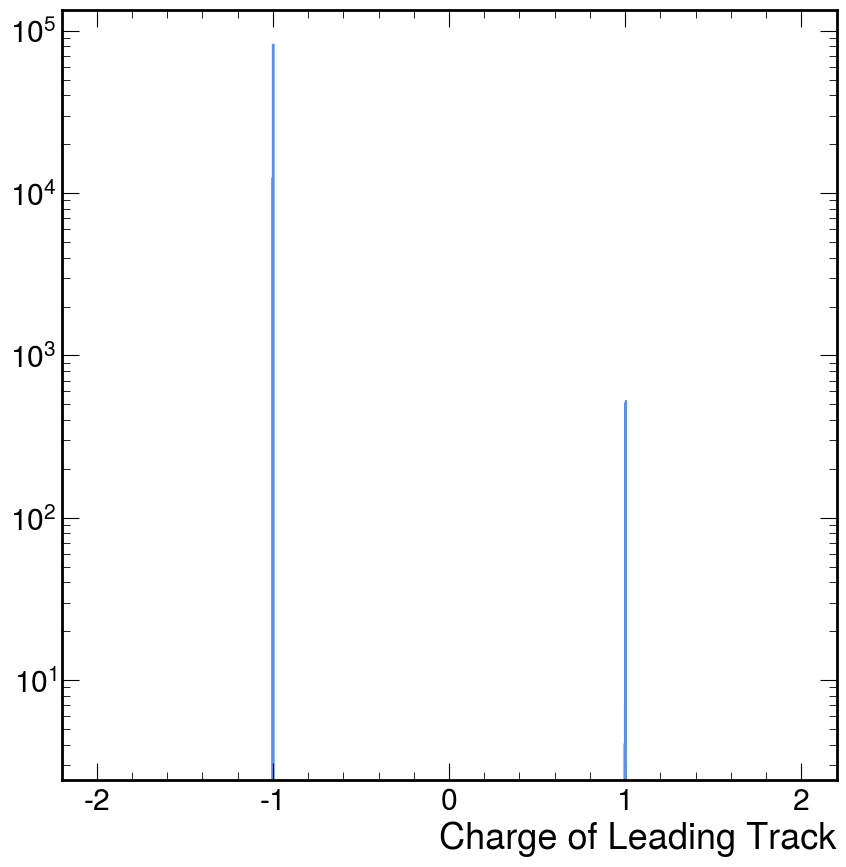

<Figure size 1000x1000 with 0 Axes>

In [28]:
f['leadtrk_charge'].to_hist().plot()
plt.yscale('log')
plt.show()
plt.savefig("leadtrk_charge.jpg")

In [79]:
thresh = 5.63 #min energy req - from cumsum plot

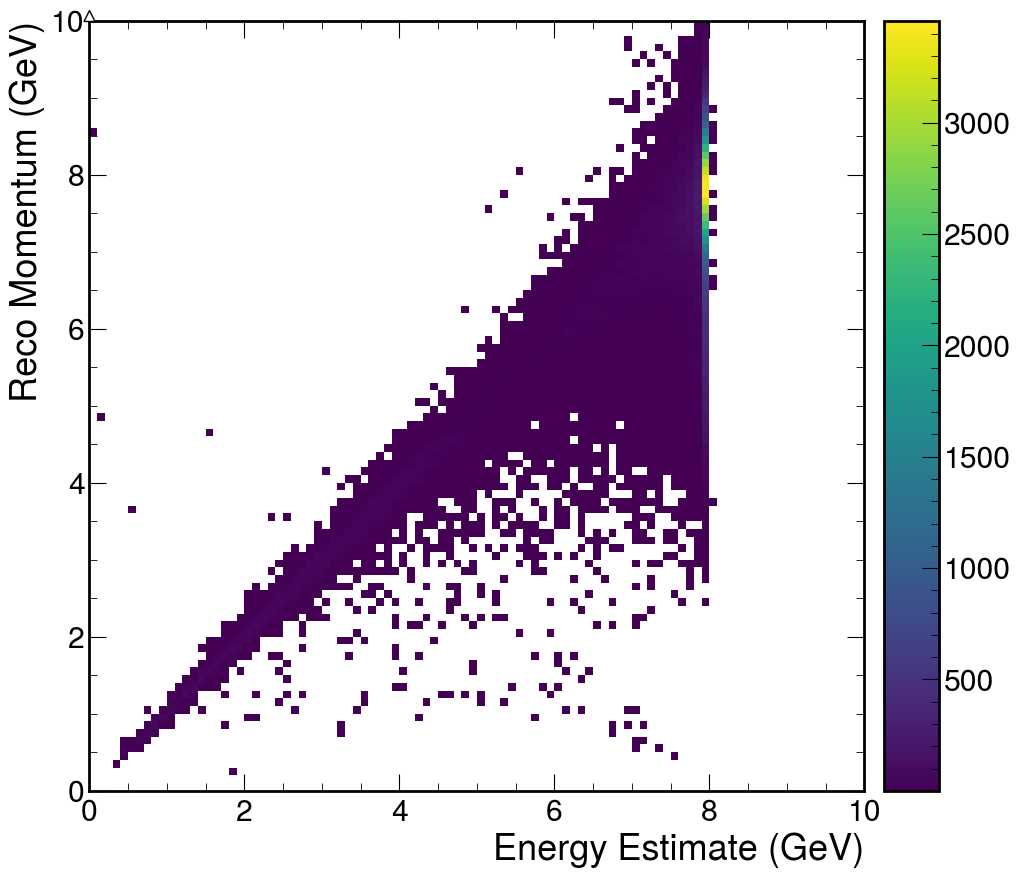

In [83]:
leadtrkr2 = f['leadtrk_reco_nhits_10_impact_cuts_vs_Energy_Estimate_R2'].to_hist()
leadtrkr2.plot(cmin=1)
#plt.xlim(-0.5, 8)
#plt.title("Leading Tracks (R=2mm)")
#plt.yscale("log")
#plt.axhline(thresh, color='gray')
#plt.savefig("leadtrk_reco_ALL_REQS_vs_Energy_Estimate_R2.jpg")
plt.show()



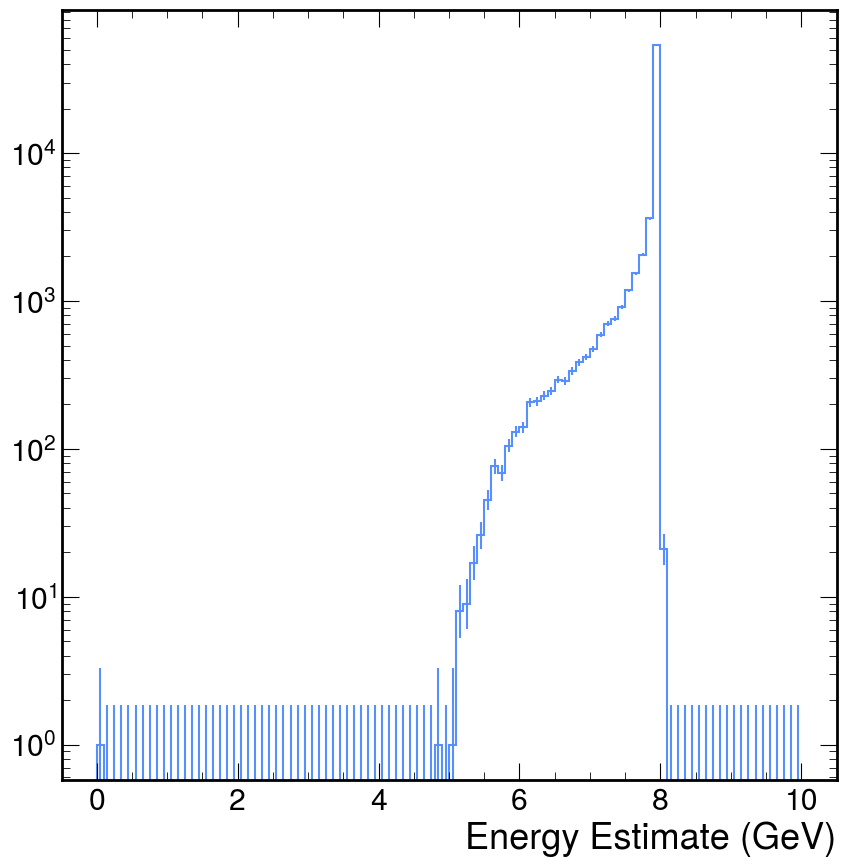

In [85]:
leadtrkr2[:,hist.loc(thresh)::sum].plot(label= "Leading Tracks (R = 2mm)")
#g.plot()
plt.yscale('log')
#plt.savefig("leadtrk_reco_vs_Lead_E_w_nearby_R2-at-thresh.jpg")
plt.show()

In [81]:
leadtrk2 = f['leadtrk_reco_vs_Lead_E_w_nearby_R2'].to_hist()
leadtrk2n10 = f['leadtrk_reco_nhits_10_vs_Lead_E_w_nearby_R2'].to_hist()

leadtrk5 = f['leadtrk_reco_vs_Lead_E_w_nearby_R5'].to_hist()
leadtrk5n10 = f['leadtrk_reco_nhits_10_vs_Lead_E_w_nearby_R5'].to_hist()

leadtrk10 = f['leadtrk_reco_vs_Lead_E_w_nearby_R10'].to_hist()
leadtrk10n10 = f['leadtrk_reco_nhits_10_vs_Lead_E_w_nearby_R10'].to_hist()


leadtrk2n10[:,hist.loc(thresh)::sum].plot(w2 = None, label = "Leading Tracks with 10 Hits (R=2)")
leadtrk2[:,hist.loc(thresh)::sum].plot(label= "Leading Tracks (R=2)")

#y.plot(label = "Leading Tracks")
plt.yscale('log')
plt.legend(loc='best')
plt.savefig("1D_leadtrk_reco_vs_Lead_E_w_nearby_R2_(hitsincluded).jpg")
plt.show()

KeyInFileError: not found: 'TrackAnalyzer_leadtrk_reco_vs_Lead_E_w_nearby_R5' (with any cycle number)

    Available keys: 'TrackAnalyzer_leadtrk_reco_vs_Lead_E_w_nearby_R2;1', 'TrackAnalyzer_leadtrk_reco_nhits_10_vs_Lead_E_w_nearby_R2;1', 'TrackAnalyzer_leading_E_vs_lead_E_w_energy_nearby_R2;1', 'TrackAnalyzer_leadtrk_reco_vs_sim_momentum;1'...

in file hist_track_ana_1.root

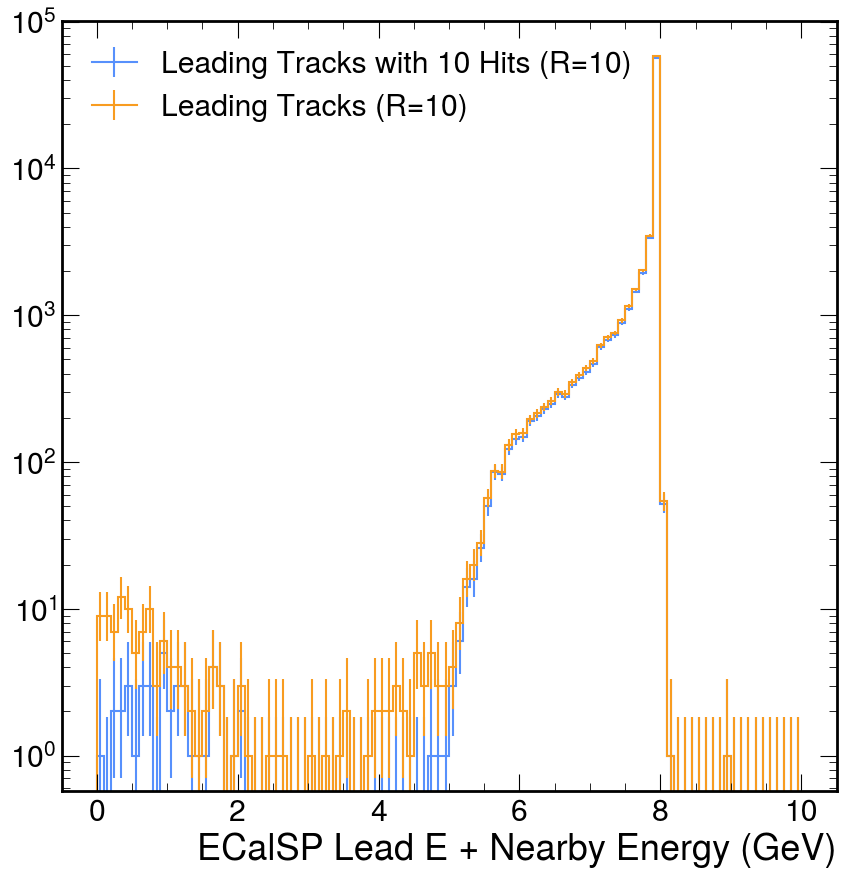

In [69]:
leadtrk5n10[:,hist.loc(thresh)::sum].plot(w2 = None, label = "Leading Tracks with 10 Hits (R=10)")
leadtrk5[:,hist.loc(thresh)::sum].plot(label= "Leading Tracks (R=10)")

#y.plot(label = "Leading Tracks")
plt.yscale('log')
plt.legend(loc='best')
plt.savefig("1D_leadtrk_reco_vs_Lead_E_w_nearby_R5_(hitsincluded).jpg")
plt.show()

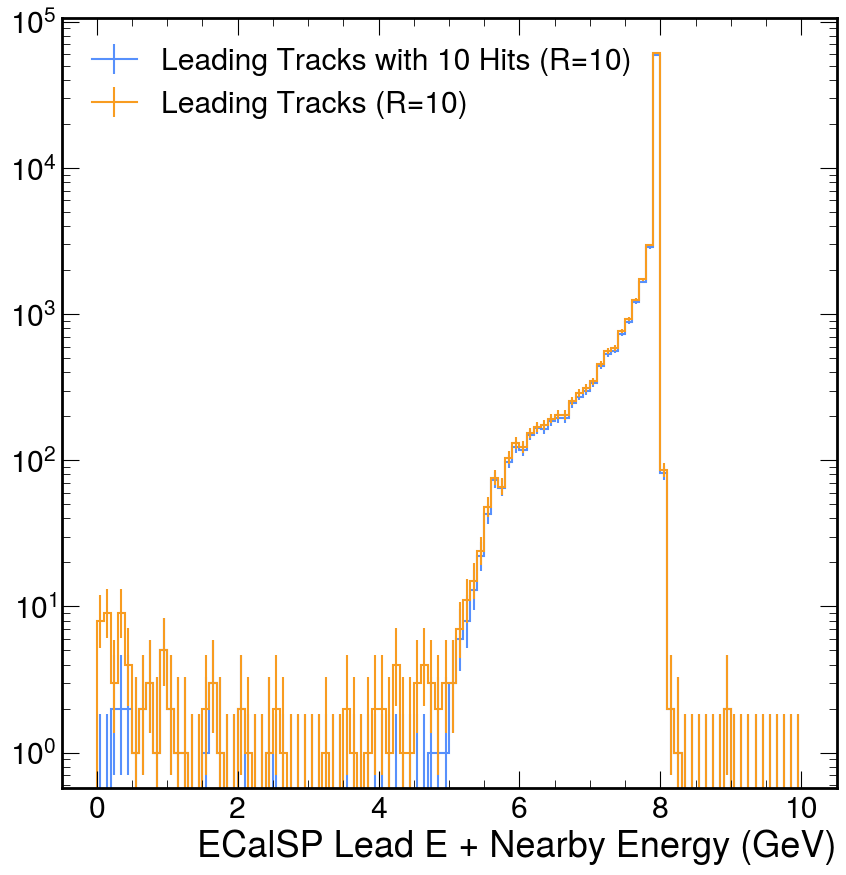

In [71]:
leadtrk10n10[:,hist.loc(thresh)::sum].plot(w2 = None, label = "Leading Tracks with 10 Hits (R=10)")
leadtrk10[:,hist.loc(thresh)::sum].plot(label= "Leading Tracks (R=10)")

#y.plot(label = "Leading Tracks")
plt.yscale('log')
plt.legend(loc='best')
plt.savefig("1D_leadtrk_reco_vs_Lead_E_w_nearby_R5_(hitsincluded).jpg")
plt.show()

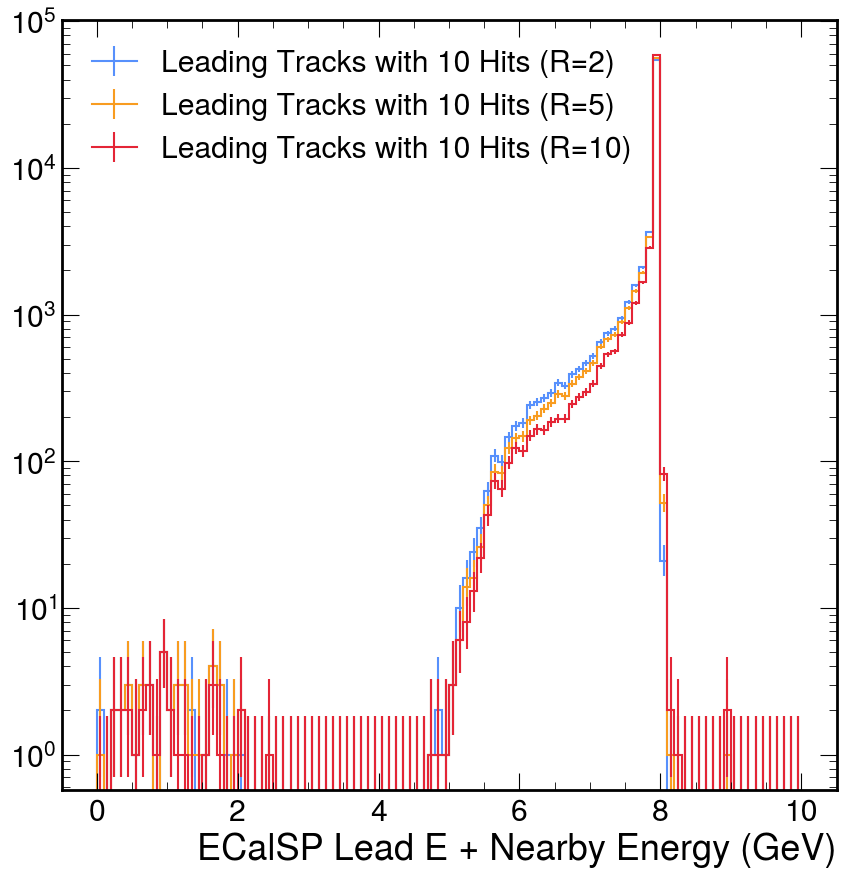

In [60]:
leadtrk2n10[:,hist.loc(thresh)::sum].plot(w2 = None, label = "Leading Tracks with 10 Hits (R=2)")
#leadtrk2[:,hist.loc(thresh)::sum].plot(label= "Leading Tracks (R=2)")

leadtrk5n10[:,hist.loc(thresh)::sum].plot(w2 = None, label = "Leading Tracks with 10 Hits (R=5)")
#leadtrk5[:,hist.loc(thresh)::sum].plot(label= "Leading Tracks (R=5)")

leadtrk10n10[:,hist.loc(thresh)::sum].plot(w2 = None, label = "Leading Tracks with 10 Hits (R=10)")
#leadtrk10[:,hist.loc(thresh)::sum].plot(label= "Leading Tracks (R=10)")


#y.plot(label = "Leading Tracks")
plt.yscale('log')
plt.legend(loc='best')
plt.savefig("1D_10_Hits_leadtrk_reco_vs_Lead_E_w_nearby.jpg")
plt.show()

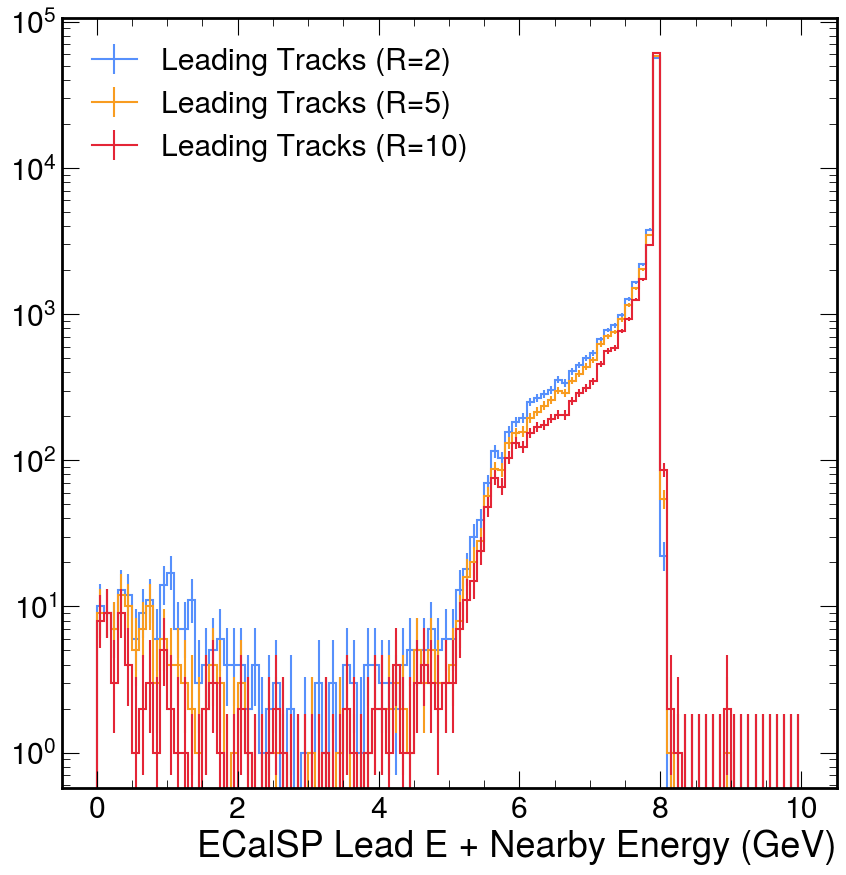

In [62]:
leadtrk2[:,hist.loc(thresh)::sum].plot(label= "Leading Tracks (R=2)")

leadtrk5[:,hist.loc(thresh)::sum].plot(label= "Leading Tracks (R=5)")

leadtrk10[:,hist.loc(thresh)::sum].plot(label= "Leading Tracks (R=10)")

plt.yscale('log')
plt.legend(loc='best')
plt.savefig("1D_leadtrk_reco_vs_Lead_E_w_nearby.jpg")
plt.show()

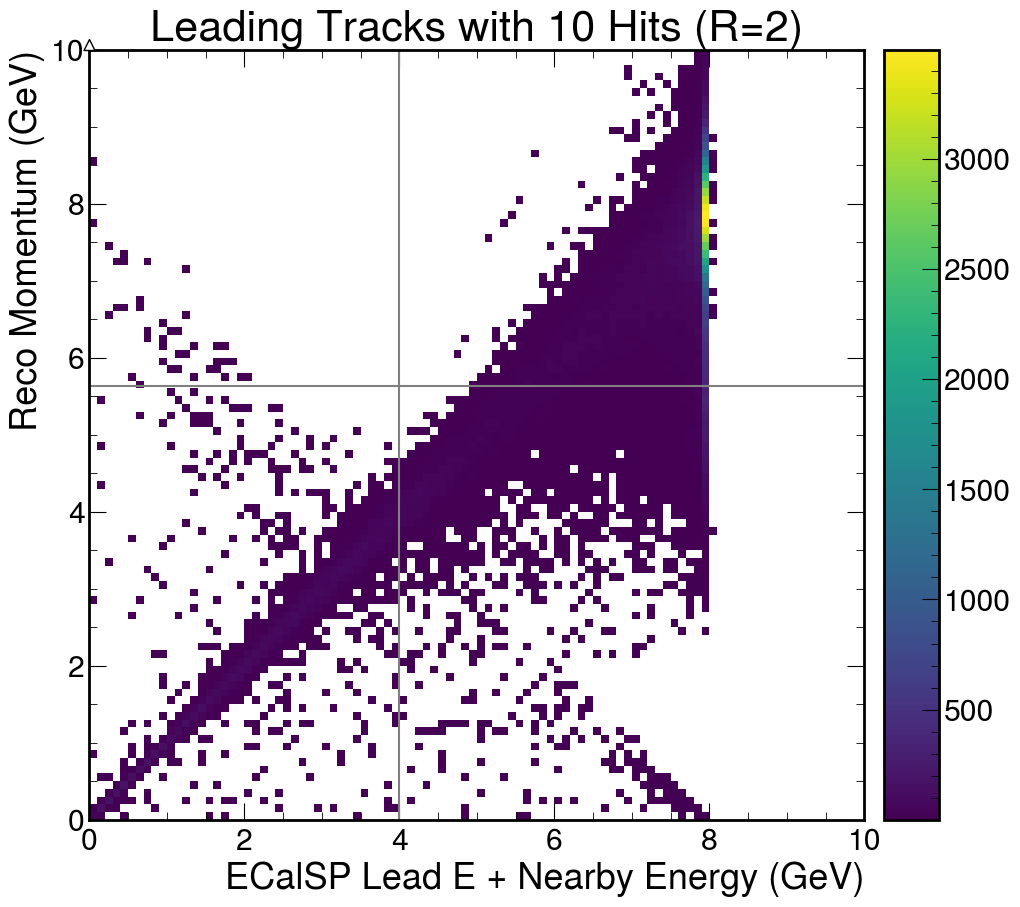

In [22]:
h = f['leadtrk_reco_nhits_10_vs_Lead_E_w_nearby_R2'].to_hist().plot(cmin=1)
plt.title("Leading Tracks with 10 Hits (R=2)")
#plt.xlim(-0.5, 8)
plt.axhline(thresh, color='gray')
plt.axvline(4, color='gray')

#plt.yscale("log")
#plt.savefig("leadtrk_reco_vs_Lead_E_w_nearby.jpg")
#h[:,hist.loc(6)::sum].plot()
#plt.yscale('log')
plt.savefig("leadtrk_reco_vs_Lead_E_w_nearby_R2_N10.jpg")
plt.show()

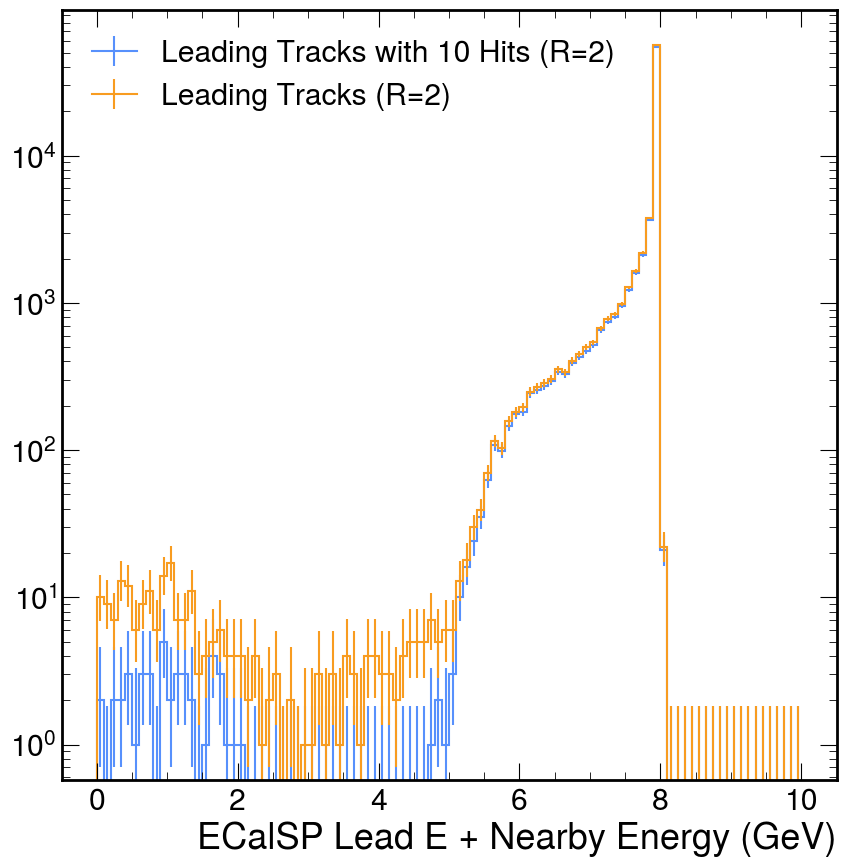

In [26]:

leadtrk2n10[:,hist.loc(thresh)::sum].plot(w2 = None, label = "Leading Tracks with 10 Hits (R=2)")
leadtrk2[:,hist.loc(thresh)::sum].plot(label= "Leading Tracks (R=2)")

plt.yscale('log')
plt.legend(loc='best')
plt.savefig("1D_leadtrk_reco_vs_Lead_E_w_nearby.jpg")
plt.show()

Text(0.5, 1.0, 'Leading Tracks(R=5)')

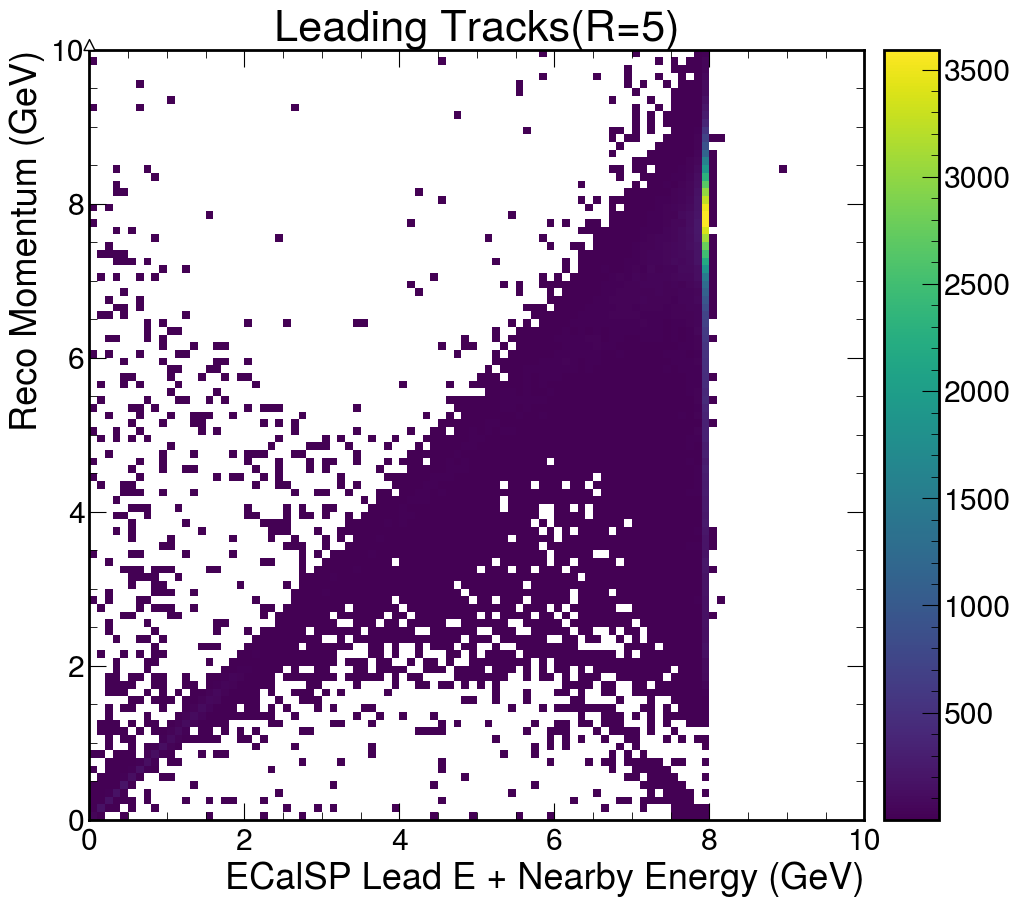

In [44]:
leadtrk5 = f['leadtrk_reco_vs_Lead_E_w_nearby_R5'].to_hist().plot(cmin=1)
plt.title("Leading Tracks(R=5)")
#plt.xlim(-0.5, 8)
#plt.yscale("log")
#plt.savefig("leadtrk_reco_vs_Lead_E_w_nearby.jpg")

Text(0.5, 1.0, 'Leading Tracks with 10 Hits (R=5)')

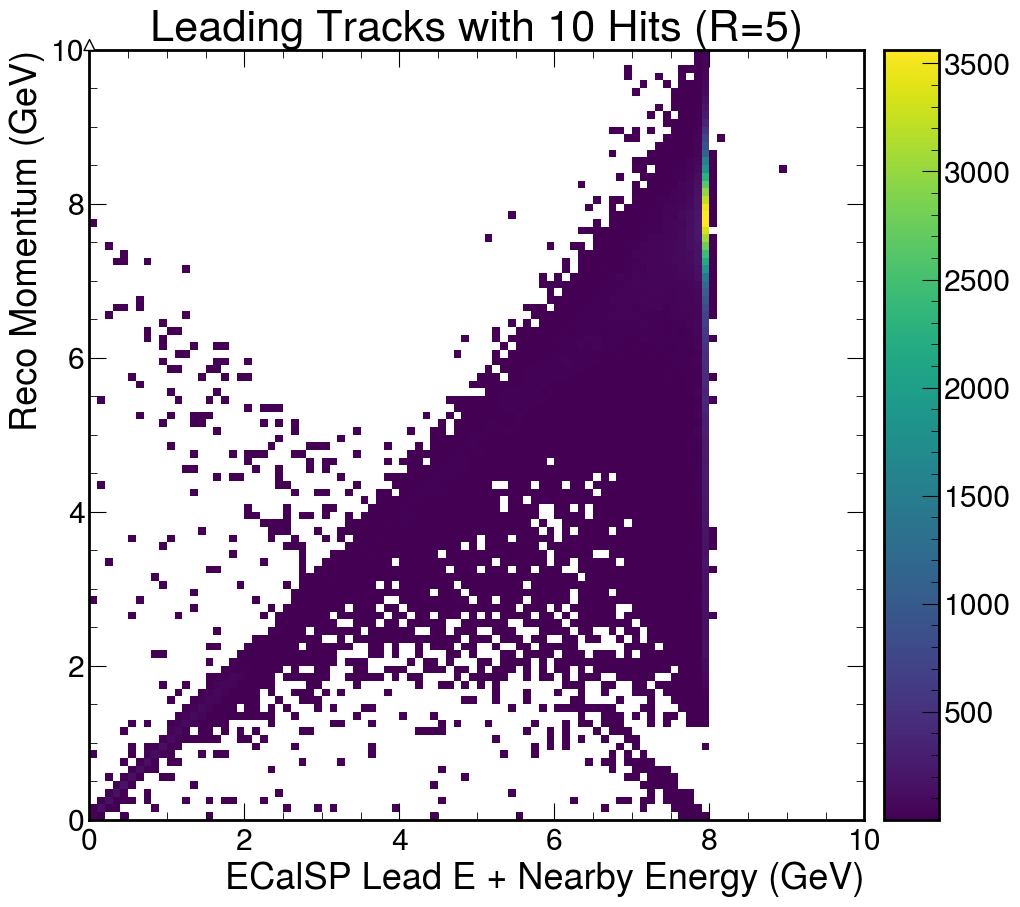

In [45]:
leadtrk5n10 = f['leadtrk_reco_nhits_10_vs_Lead_E_w_nearby_R5'].to_hist().plot(cmin=1)
plt.title("Leading Tracks with 10 Hits (R=5)")
#plt.xlim(-0.5, 8)
#plt.yscale("log")
#plt.savefig("leadtrk_reco_vs_Lead_E_w_nearby.jpg")

In [47]:
leadtrk5[:,hist.loc(thresh)::sum].plot(label= "Leading Tracks (R = 5)")
leadtrk5n10[:,hist.loc(thresh)::sum].plot(label= "Leading Tracks with 10 Hits (R = 5)")

TypeError: tuple indices must be integers or slices, not tuple

Text(0.5, 1.0, 'Leading Tracks(R=10)')

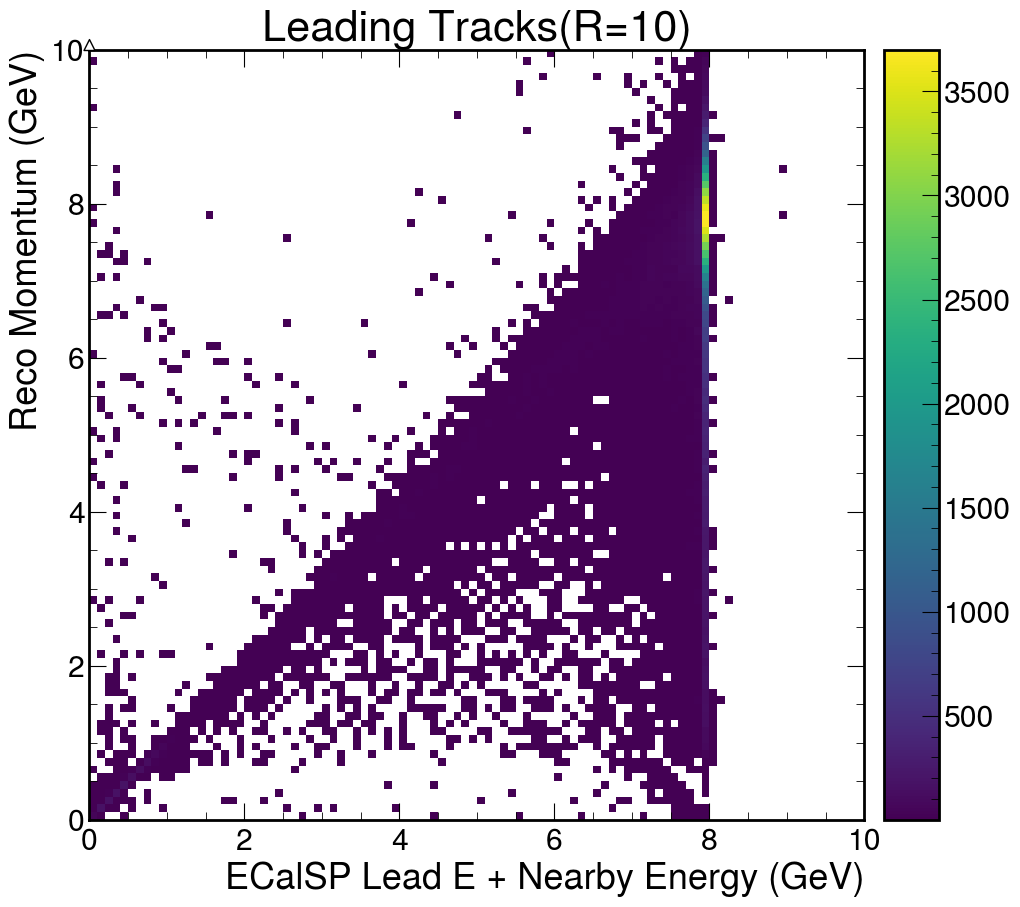

In [32]:
h = f['leadtrk_reco_vs_Lead_E_w_nearby_R10'].to_hist().plot(cmin=1)
plt.title("Leading Tracks(R=10)")
#plt.xlim(-0.5, 8)
#plt.yscale("log")
#plt.savefig("leadtrk_reco_vs_Lead_E_w_nearby.jpg")

In [ ]:
h = f['leadtrk_reco_nhits_10_vs_Lead_E_w_nearby_R10'].to_hist()
h.plot(cmin=1)
plt.title("Leading Tracks with 10 Hits (R=10)")
#plt.xlim(-0.5, 8)
#plt.yscale("log")
#plt.savefig("leadtrk_reco_vs_Lead_E_w_nearby.j

h[6j::sum,:].plot()

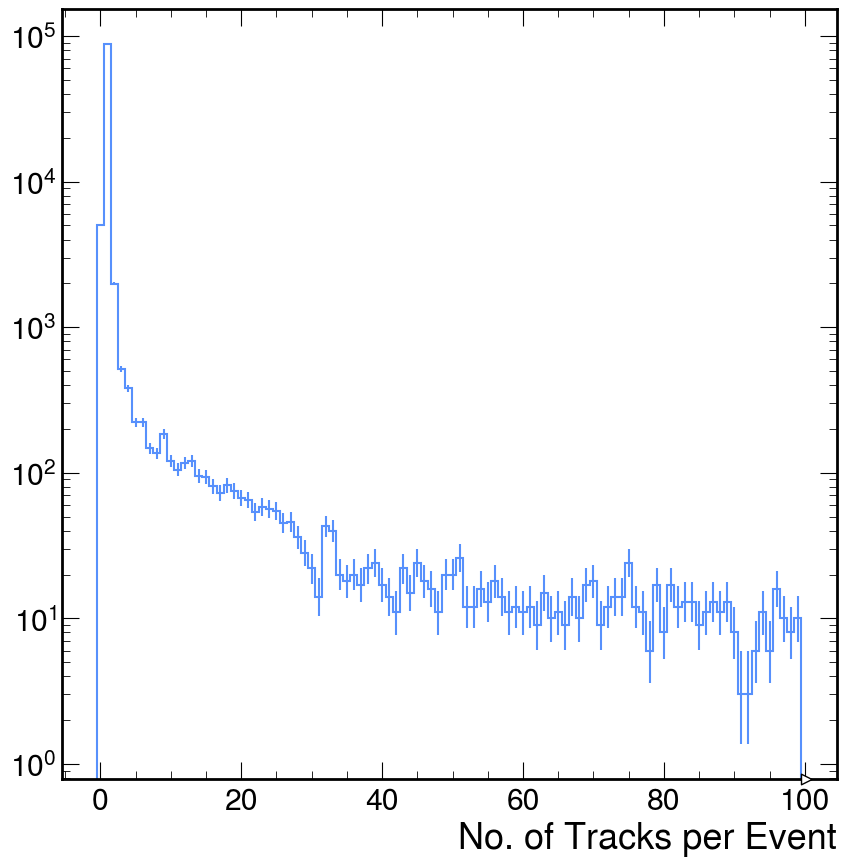

In [7]:
h = f['event_tracks'].to_hist().plot()
#plt.xlim(-0.5, 10)
plt.yscale("log")
#plt.savefig("tracks_per_event_log.jpg")

In [10]:
#h = f['clean_event_tracks'].to_hist().plot()
#plt.xlim(-0.5, 10)
#plt.yscale("log")
#plt.savefig("clean_tracks_per_event_range_10.jpg")

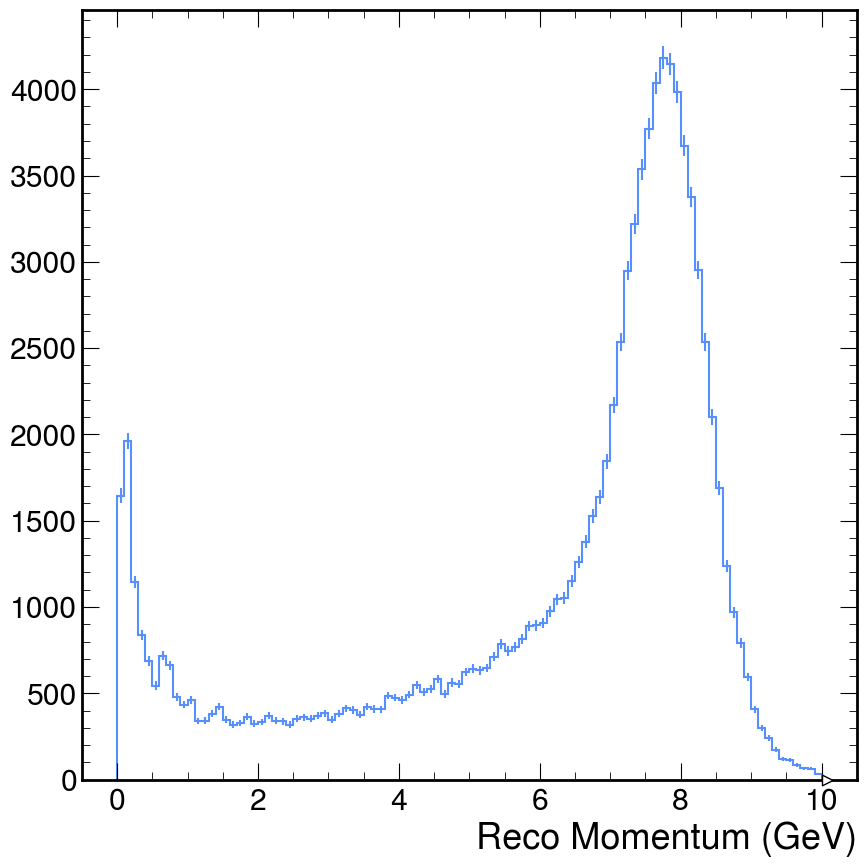

In [26]:
g = f['reco_momentum'].to_hist().plot()
#plt.savefig("reco_momentum.jpg")

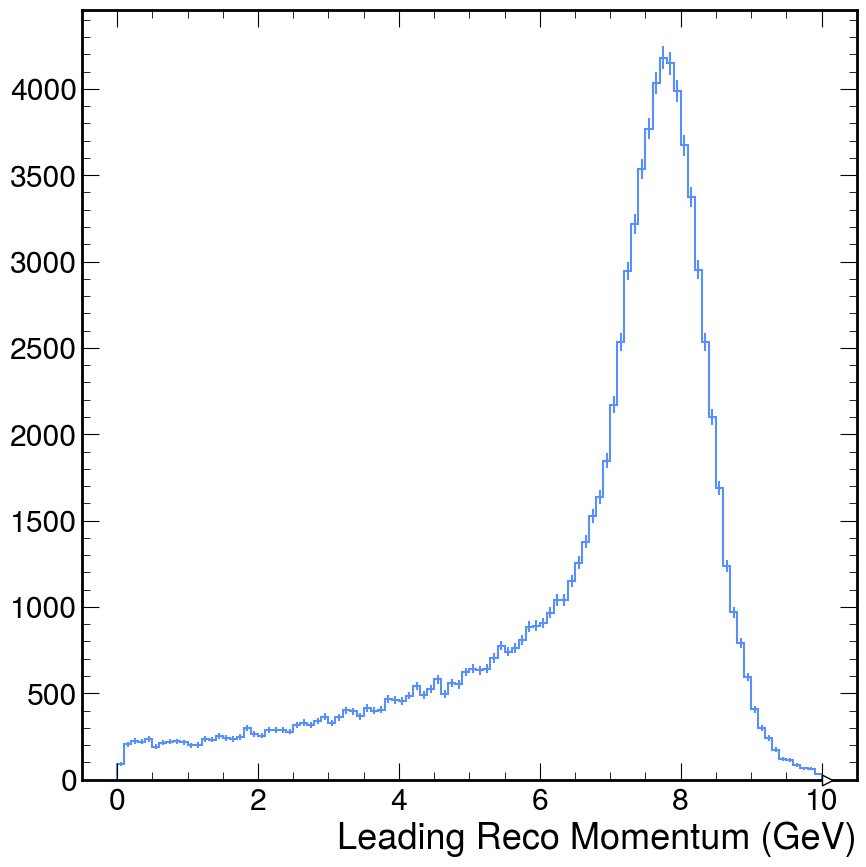

In [27]:
g = f['reco_leadtrk_momentum'].to_hist().plot()
#plt.savefig("leadtrk_reco_momentum.jpg")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


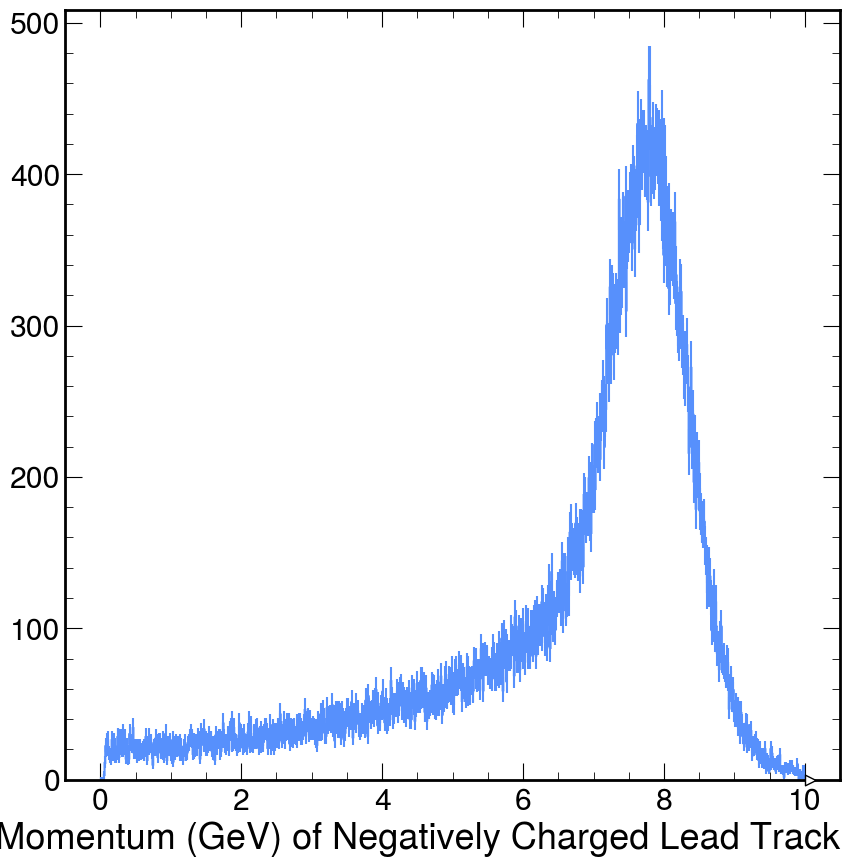

In [20]:
g = f['reco_leadtrk_momentum_neg_charge'].to_hist().plot()
#plt.yscale("log")
#plt.savefig("leadtrk_reco_momentum-log.jpg")

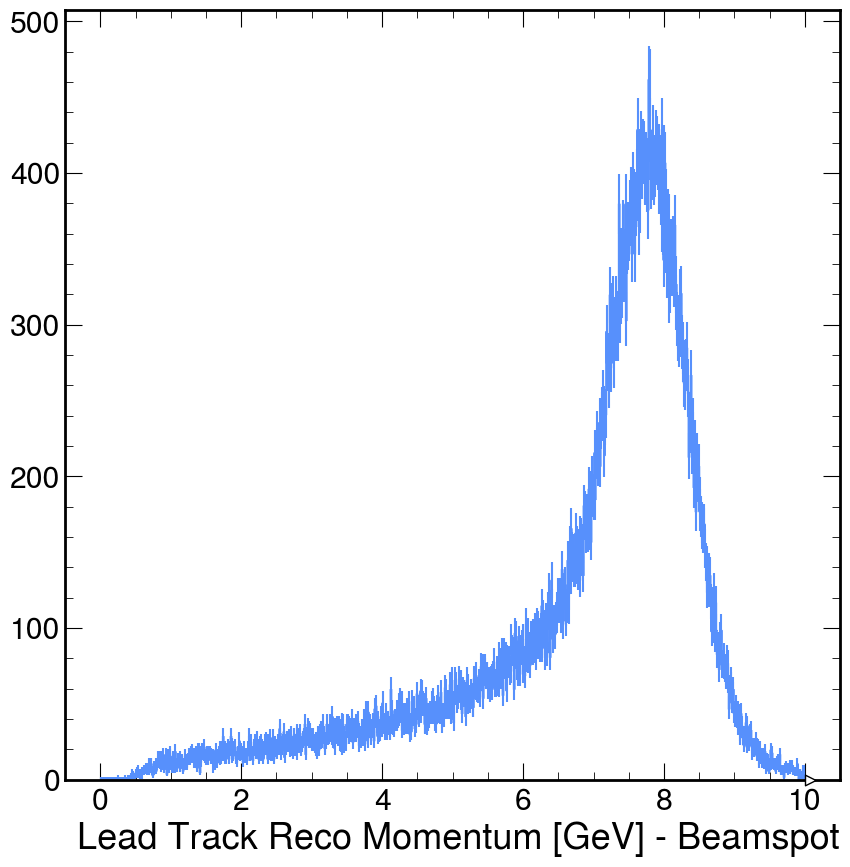

In [33]:
g = f['reco_leadtrk_momentum_impact_cuts'].to_hist().plot()
plt.xlabel('Lead Track Reco Momentum [GeV] - Beamspot')
plt.savefig("leadtrk_reco_momentum_impact_cuts.jpg")

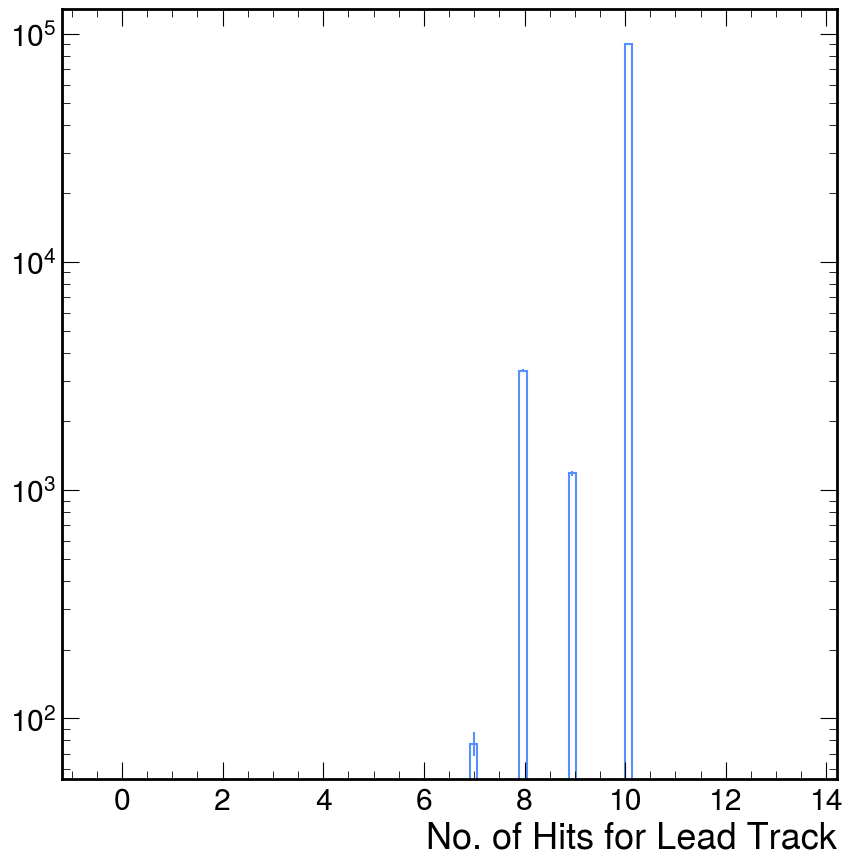

In [33]:
g = f["n_hits"].to_hist().plot()
plt.yscale("log")
plt.savefig("leadtrk_nhits.jpg")

90.0 3.53
75.0 5.93


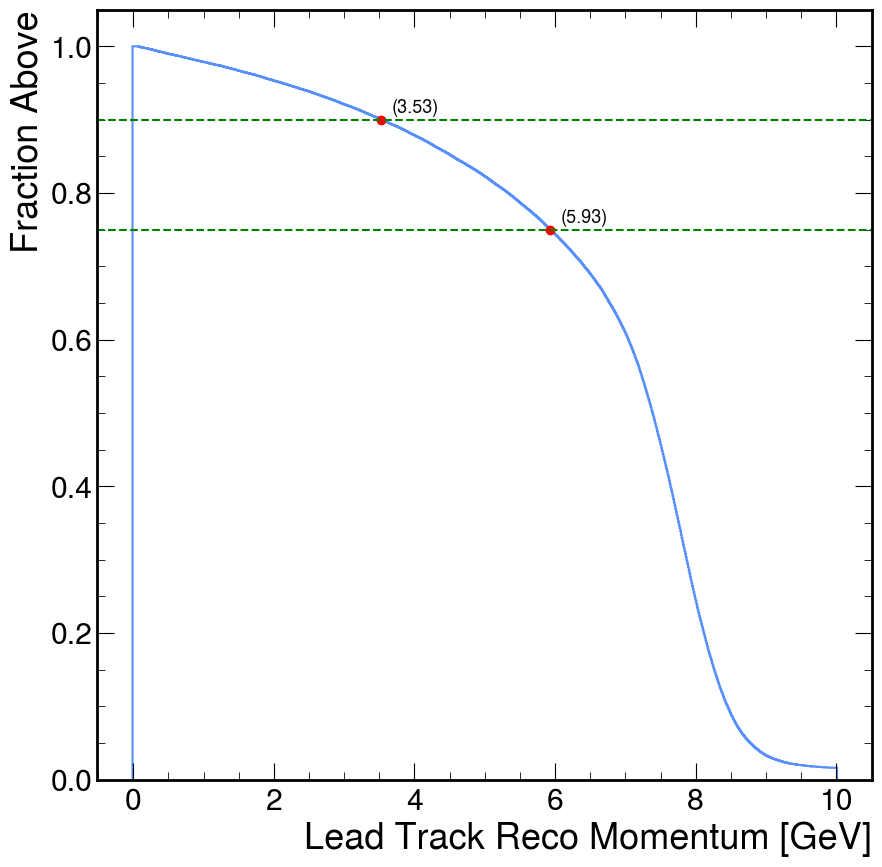

In [12]:
h = f['reco_leadtrk_momentum'].to_hist()
import numpy as np

fraction_above = np.flip(np.cumsum(np.flip(h.values(flow=True))))/np.sum(h.values(flow=True))
momentum = np.concatenate(([h.axes[0].edges[0]-0.01],h.axes[0].edges,[h.axes[0].edges[-1]+0.01]))

mplhep.histplot(fraction_above, bins = momentum)

for thresh in (0.9, 0.75):
    first_above = momentum[np.argmin(fraction_above>thresh)]
    print(100*thresh, first_above)
    #plt.annotate(f'(90%, {first_above:.2f} GeV)', (0.9,first_above), va='bottom', ha='left')
    #plt.axvline(first_above, label = " str(first_above) +, color = "r")
    plt.plot(first_above,thresh,'ro') 
    plt.text(first_above+0.15, thresh+0.01, f"({np.round(first_above,decimals=2)})", fontsize=13)
    plt.axhline(thresh, color = "g", linestyle='--')

plt.xlabel('Lead Track Reco Momentum [GeV]')
plt.ylabel('Fraction Above')
#plt.legend(loc= "best")
plt.savefig("cumsum_plot.jpg")

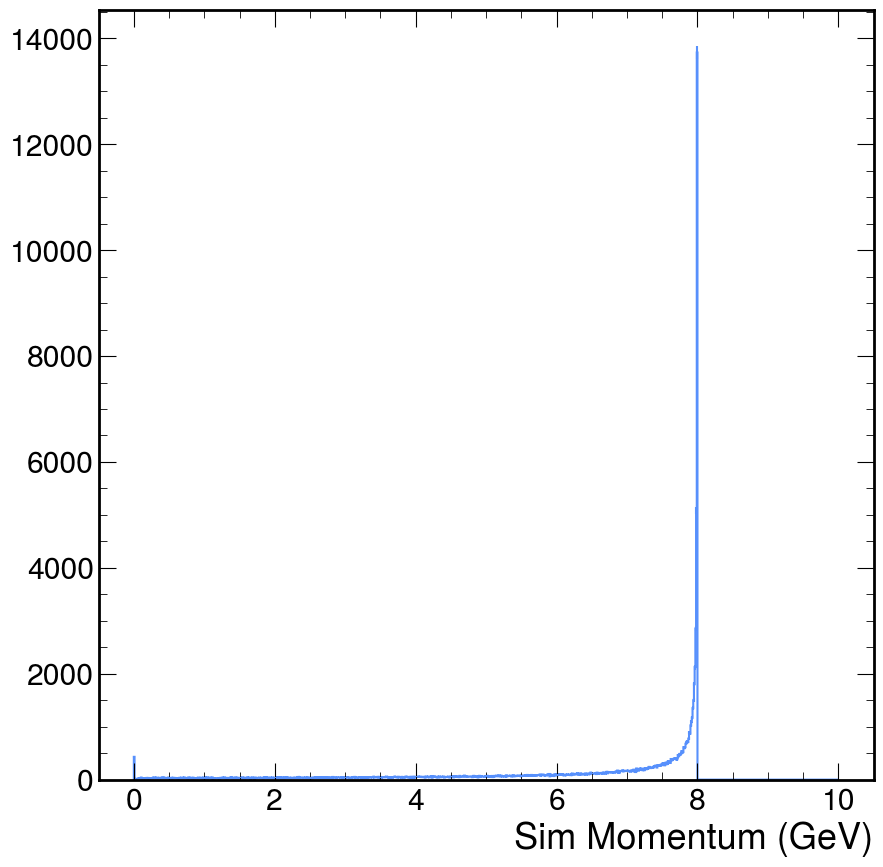

In [13]:
h = f['sim_momentum'].to_hist().plot(label = "Sim Momentum")
plt.savefig("sim_momentum.jpg")

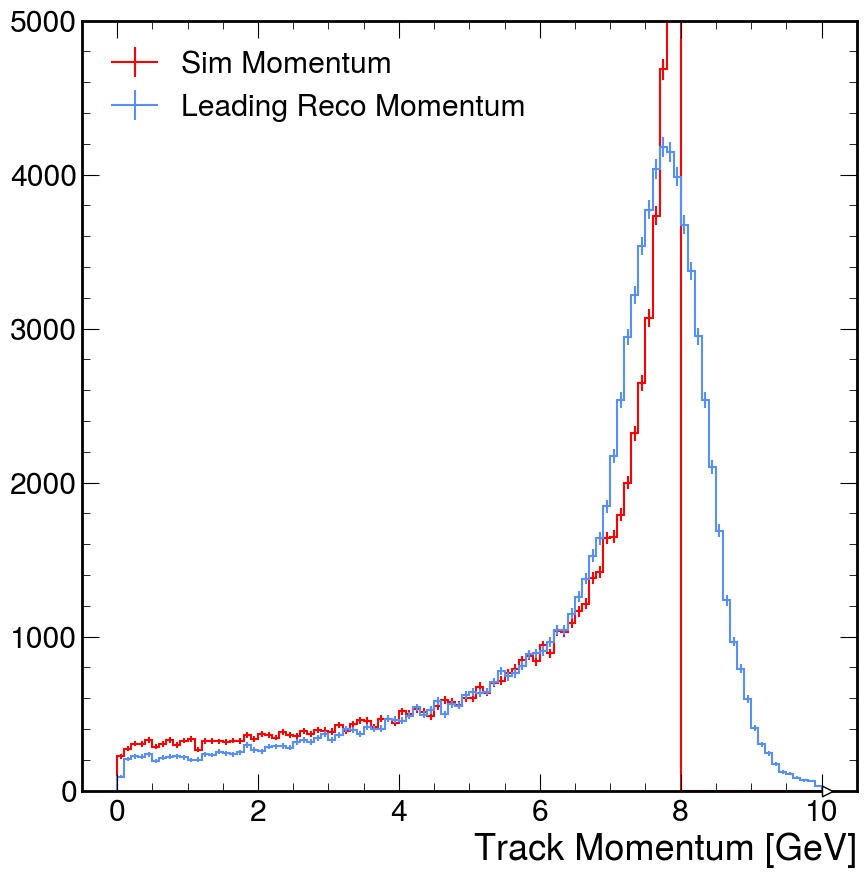

In [42]:
hh = f['sim_momentum'].to_hist()
#for i in range(0,len(hh.axes[0].widths)):
   # hh[i]=hh[i]*0.05
h = hh.plot(color ="red",label = "Sim Momentum")
g = f['reco_leadtrk_momentum'].to_hist().plot(label = "Leading Reco Momentum")
plt.legend(loc='best')
plt.xlabel('Track Momentum [GeV]')
plt.ylim(0,5000)
#plt.yscale("log")
plt.savefig("sim_vs_lead_reco_NO_CUTS.jpg")

Text(1, 0, 'Track Momentum [GeV]')

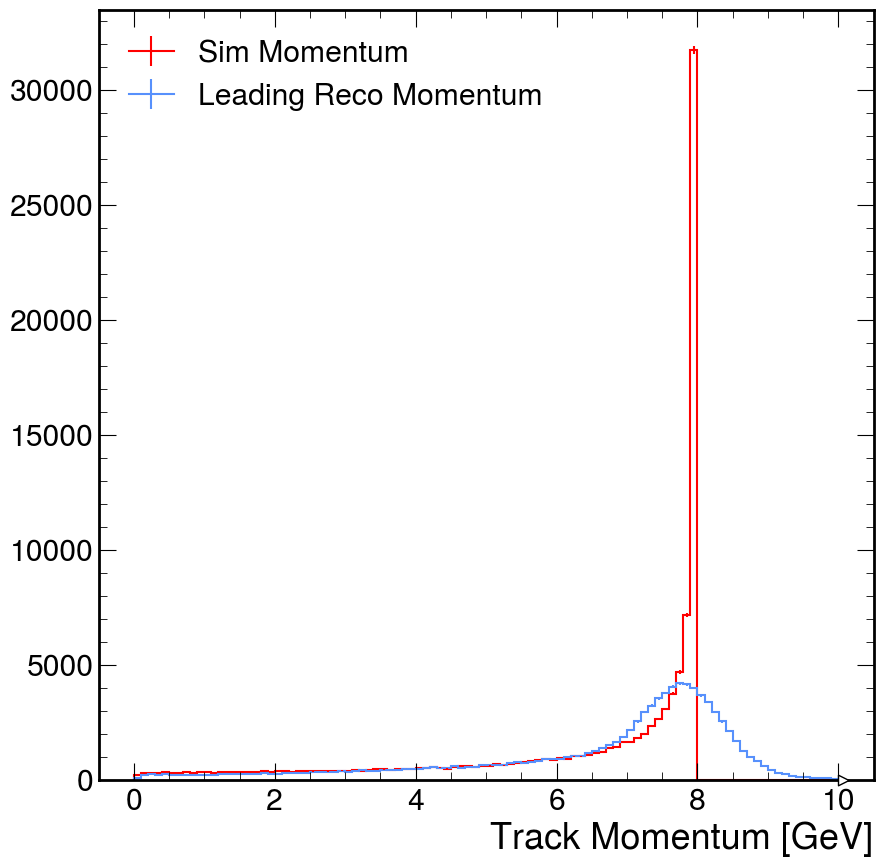

In [29]:
hh = f['sim_momentum'].to_hist()
#for i in range(0,len(hh.axes[0].widths)):
   # hh[i]=hh[i]*0.05
h = hh.plot(color ="red",label = "Sim Momentum")
g = f['reco_leadtrk_momentum'].to_hist().plot(label = "Leading Reco Momentum")
plt.legend(loc='best')
plt.xlabel('Track Momentum [GeV]')
#plt.yscale("log")
#plt.savefig("sim_vs_lead_reco_1D.jpg")

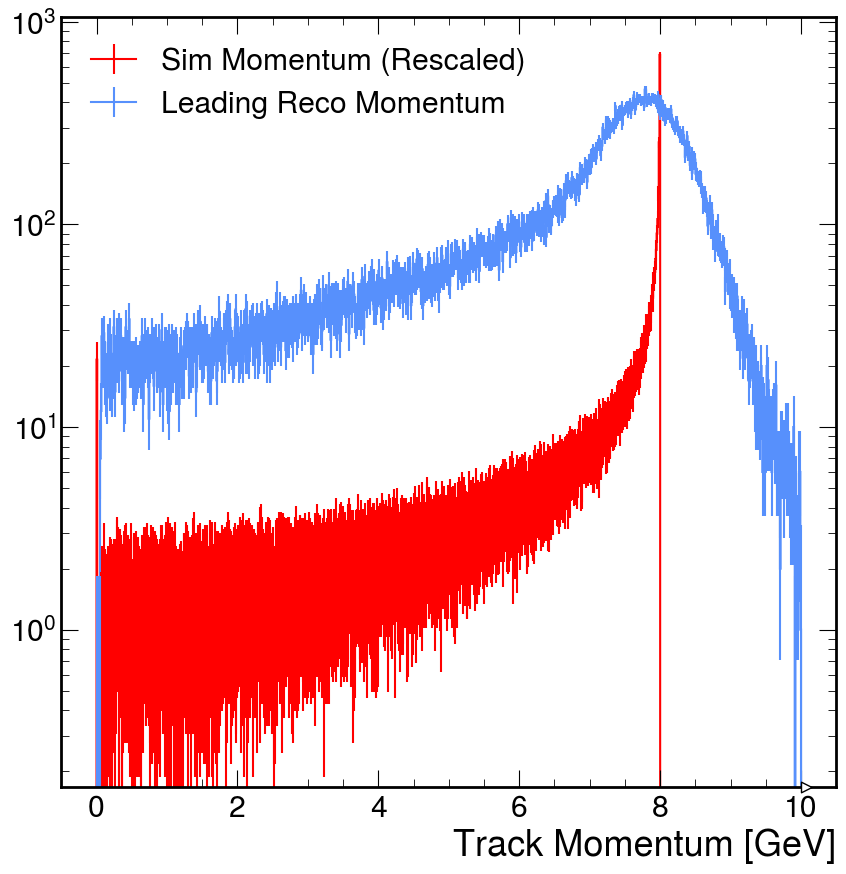

In [114]:
hh = f['sim_momentum'].to_hist()
for i in range(0,len(hh.axes[0].widths)):
    hh[i]=hh[i]*0.05
h = hh.plot(color ="red",label = "Sim Momentum (Rescaled)")
g = f['reco_leadtrk_momentum'].to_hist().plot(label = "Leading Reco Momentum")
plt.legend(loc='best')
plt.xlabel('Track Momentum [GeV]')
plt.yscale("log")
plt.savefig("recaled_sim_vs_lead_reco_1D.jpg")

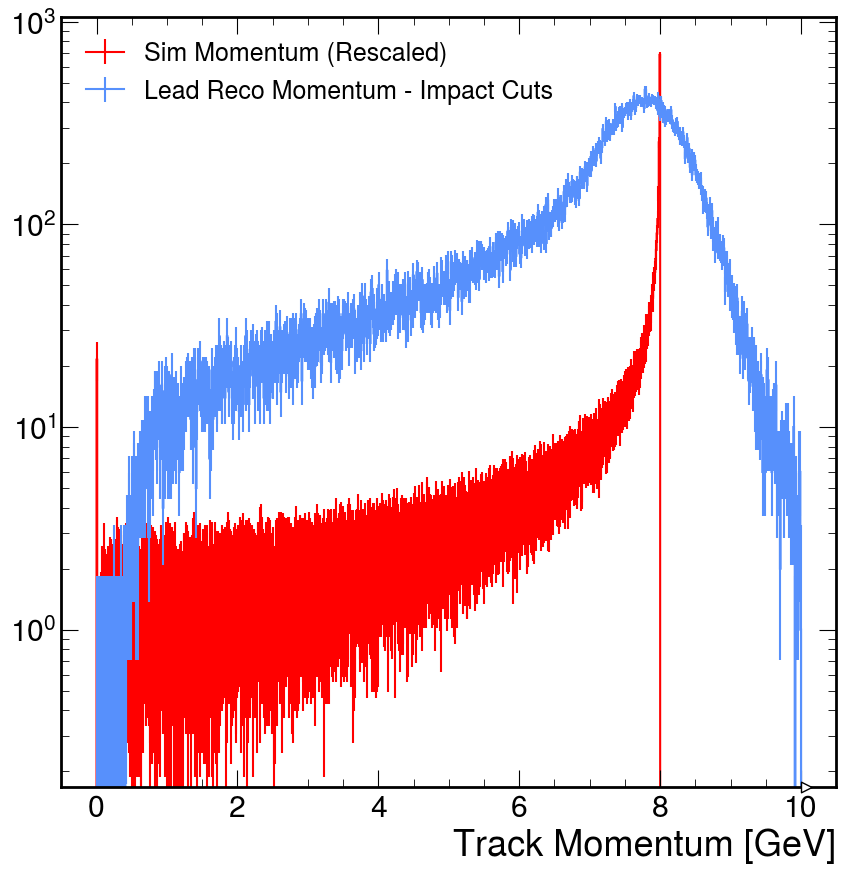

In [30]:
hh = f['sim_momentum'].to_hist()
for i in range(0,len(hh.axes[0].widths)):
    hh[i]=hh[i]*0.05
h = hh.plot(color ="red",label = "Sim Momentum (Rescaled)")
g = f['reco_leadtrk_momentum_impact_cuts'].to_hist().plot(label = "Lead Reco Momentum - Impact Cuts ")
plt.legend(loc='best', prop={'size': 18})
plt.xlabel('Track Momentum [GeV]')
plt.yscale("log")
plt.savefig("recaled_sim_vs_lead_reco_BEAMSPOT_1D.jpg")

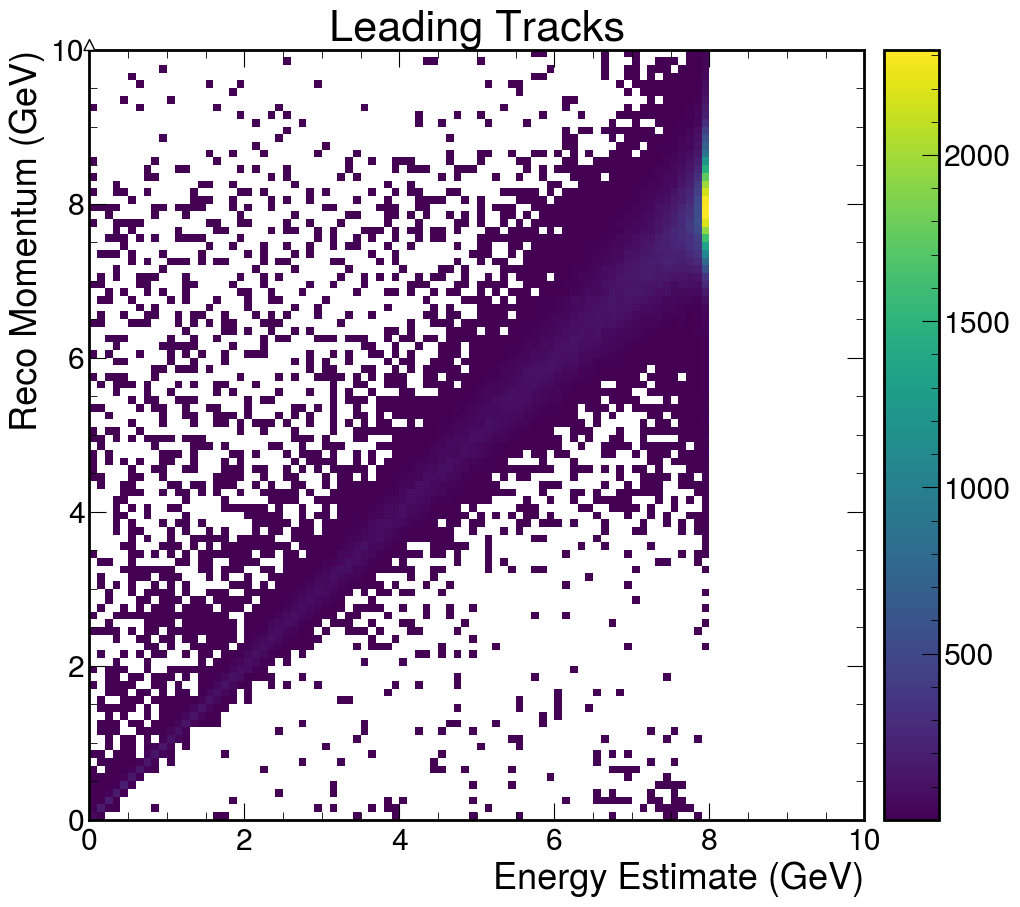

In [58]:
f['leadtrk_reco_vs_sim_momentum'].to_hist().plot(cmin=1)
plt.title("Leading Tracks")
#plt.show()
plt.savefig("leadtrk_reco_vs_sim_momentum.jpg")

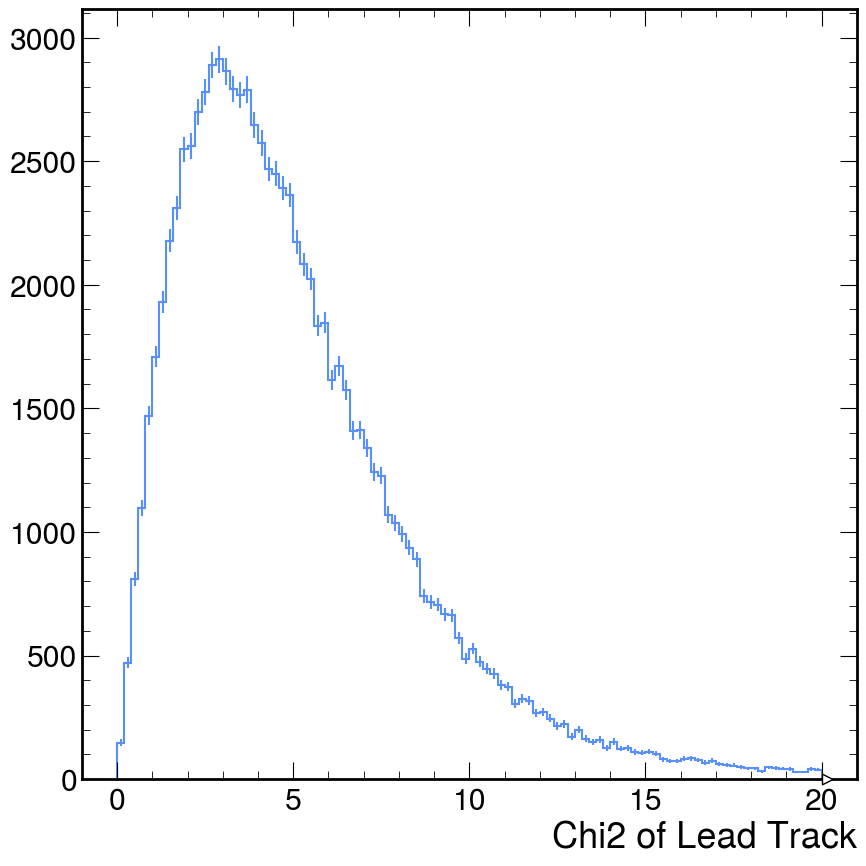

In [24]:
f['leadtrk_chi2'].to_hist().plot()
#plt.yscale("log")
plt.savefig("leadtrk_chi2_zoom.jpg")

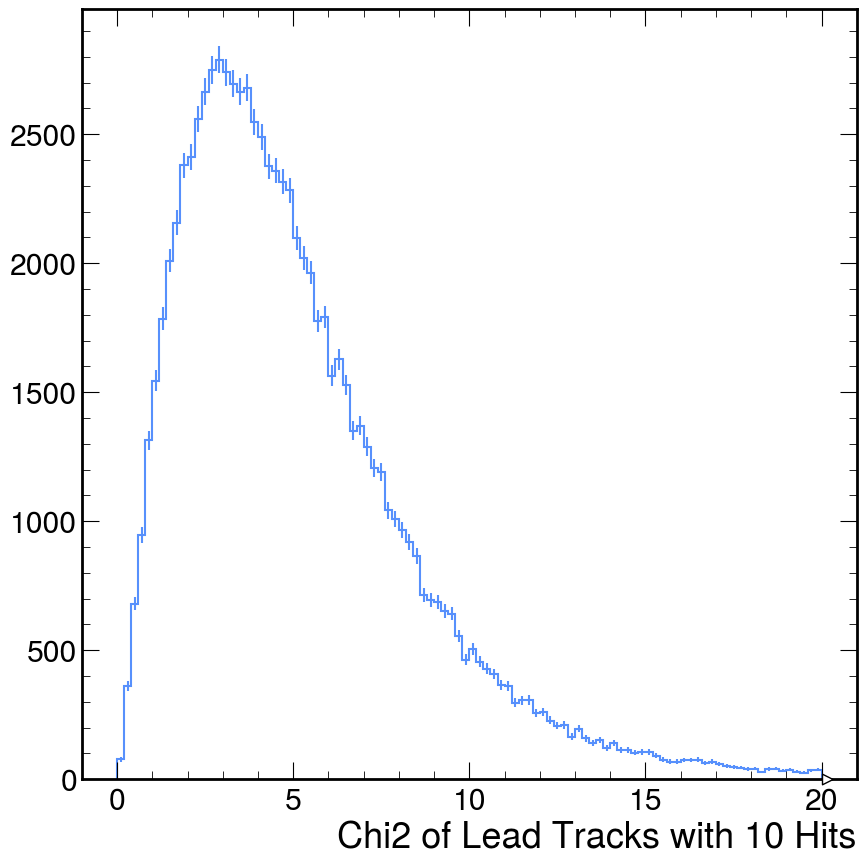

In [25]:
f['leadtrk_chi2_nhits_10'].to_hist().plot()

plt.savefig("leadtrk_chi2_nhits_10_zoom.jpg")

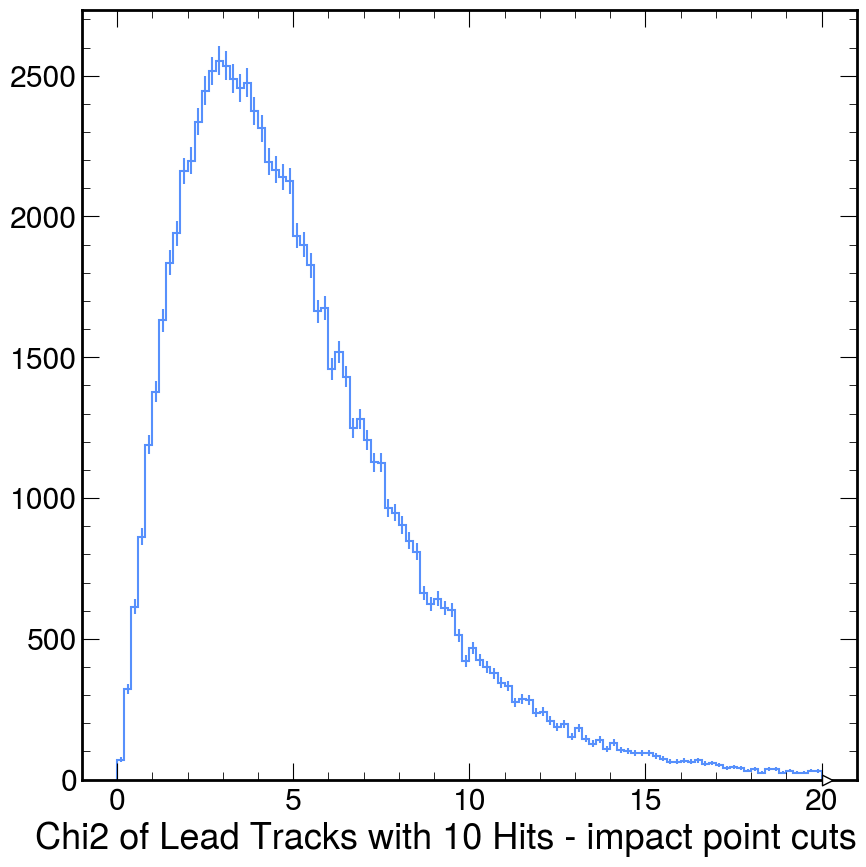

In [31]:
f['leadtrk_chi2_nhits_10_impact_cuts'].to_hist().plot()

plt.savefig("leadtrk_chi2_nhits_10_impact_cuts_zoom.jpg")

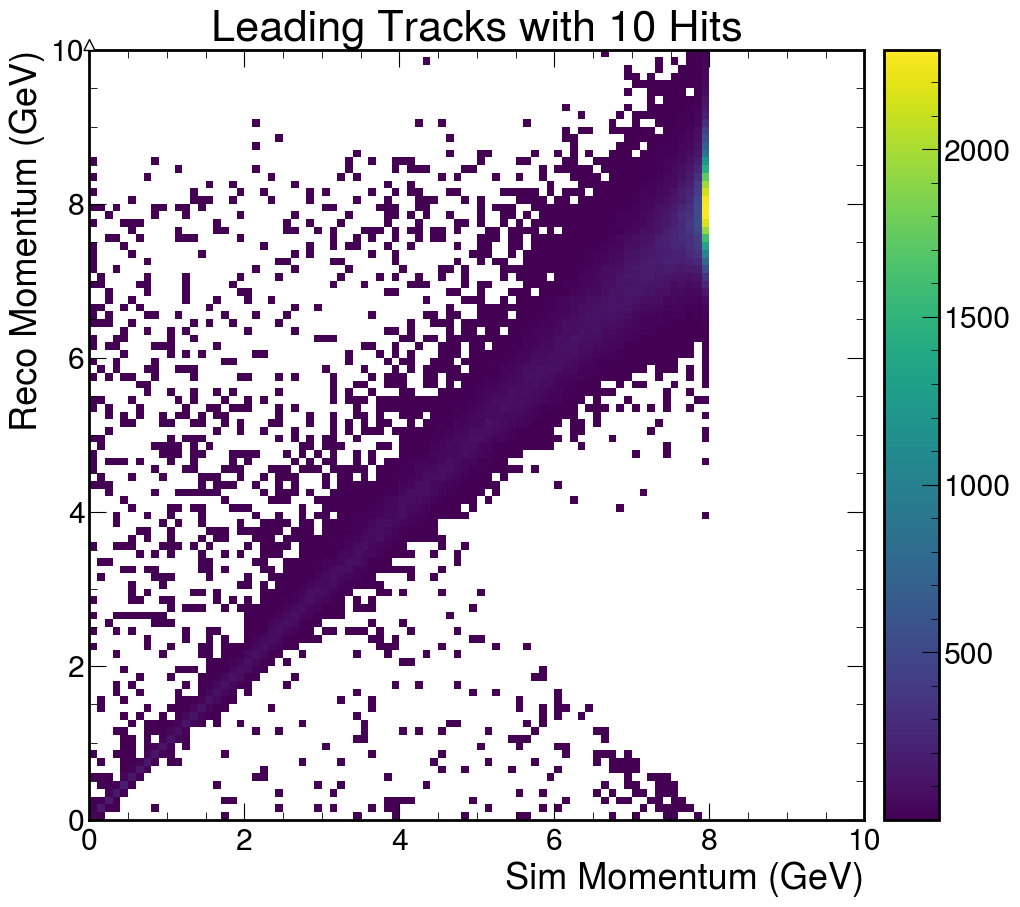

In [24]:
f['leadtrk_reco_vs_sim_momentum_nhits_10'].to_hist().plot(cmin=1)
plt.title("Leading Tracks with 10 Hits")

plt.savefig("leadtrk_reco_vs_sim_momentum_nhits_10.jpg")

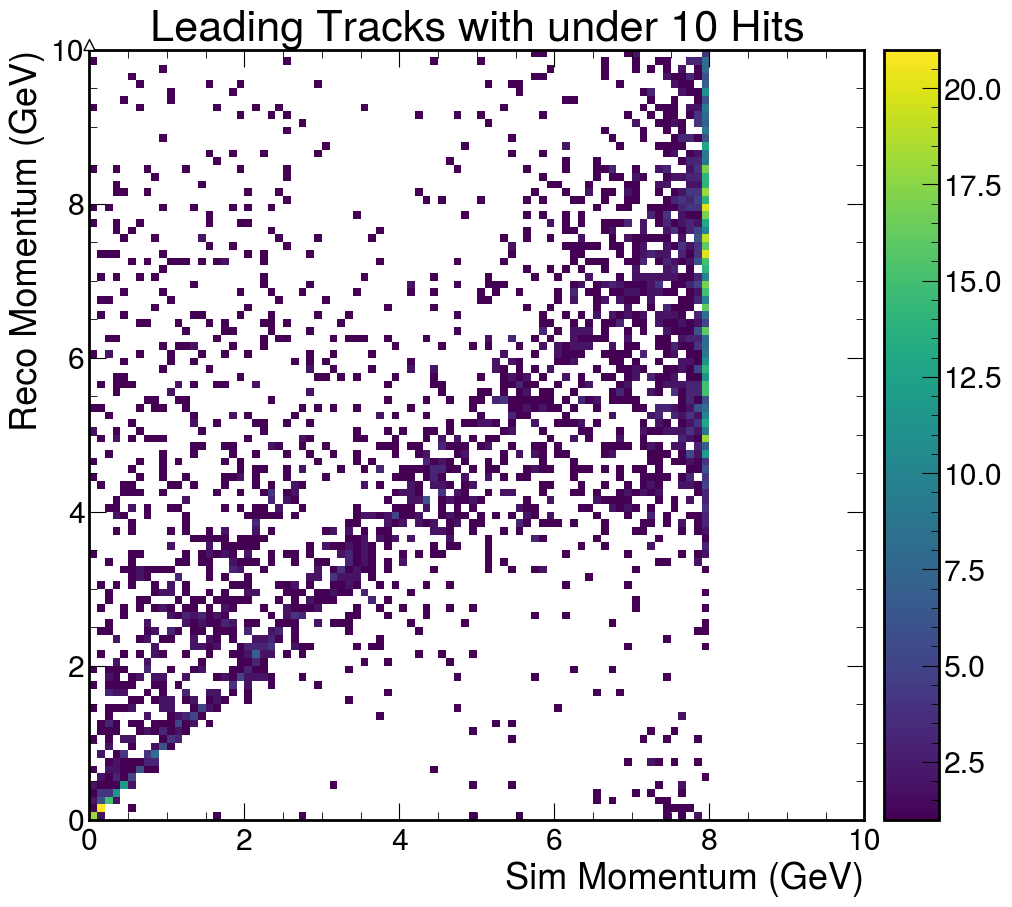

In [18]:
f['leadtrk_reco_vs_sim_momentum_nhits_under_10'].to_hist().plot(cmin=1)
plt.title("Leading Tracks with under 10 Hits")

plt.savefig("leadtrk_reco_vs_sim_momentum_nhits_under_10.jpg")

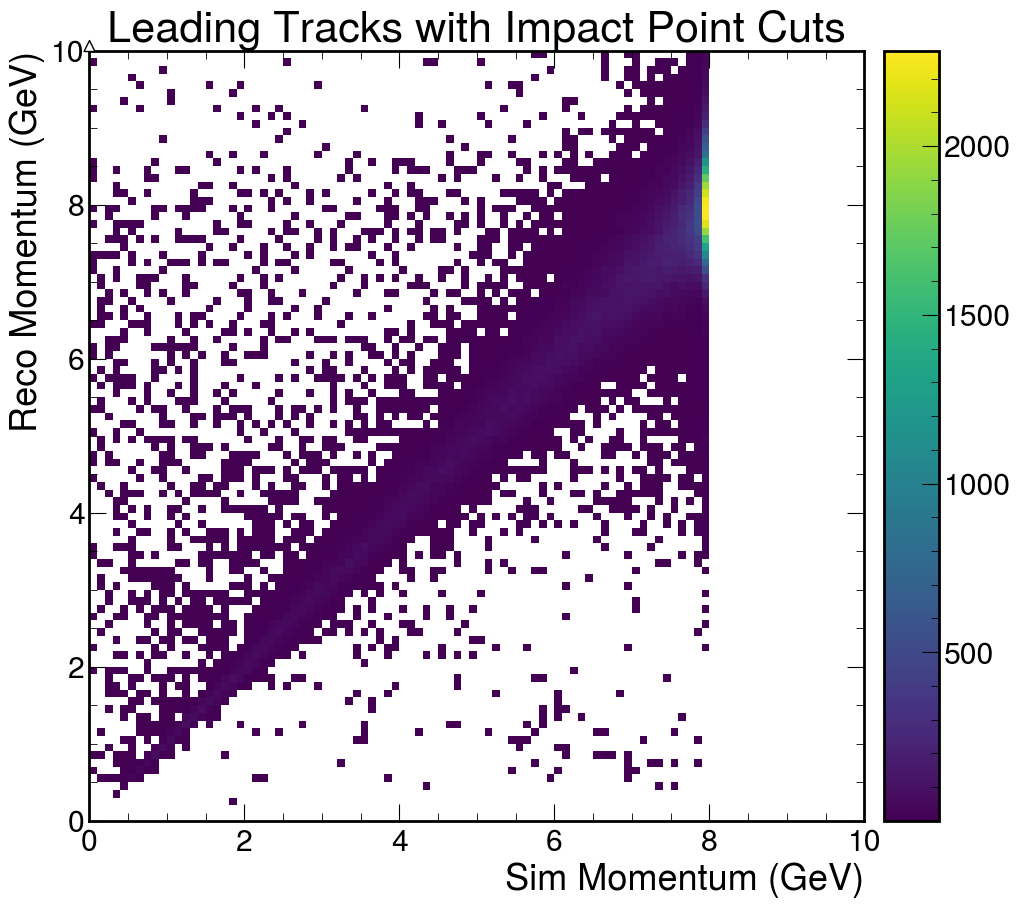

In [32]:
f['leadtrk_reco_vs_sim_momentum_impact_cuts'].to_hist().plot(cmin=1)
plt.title("Leading Tracks with Impact Point Cuts")

plt.savefig("leadtrk_reco_vs_sim_momentum_impact_cuts.jpg")

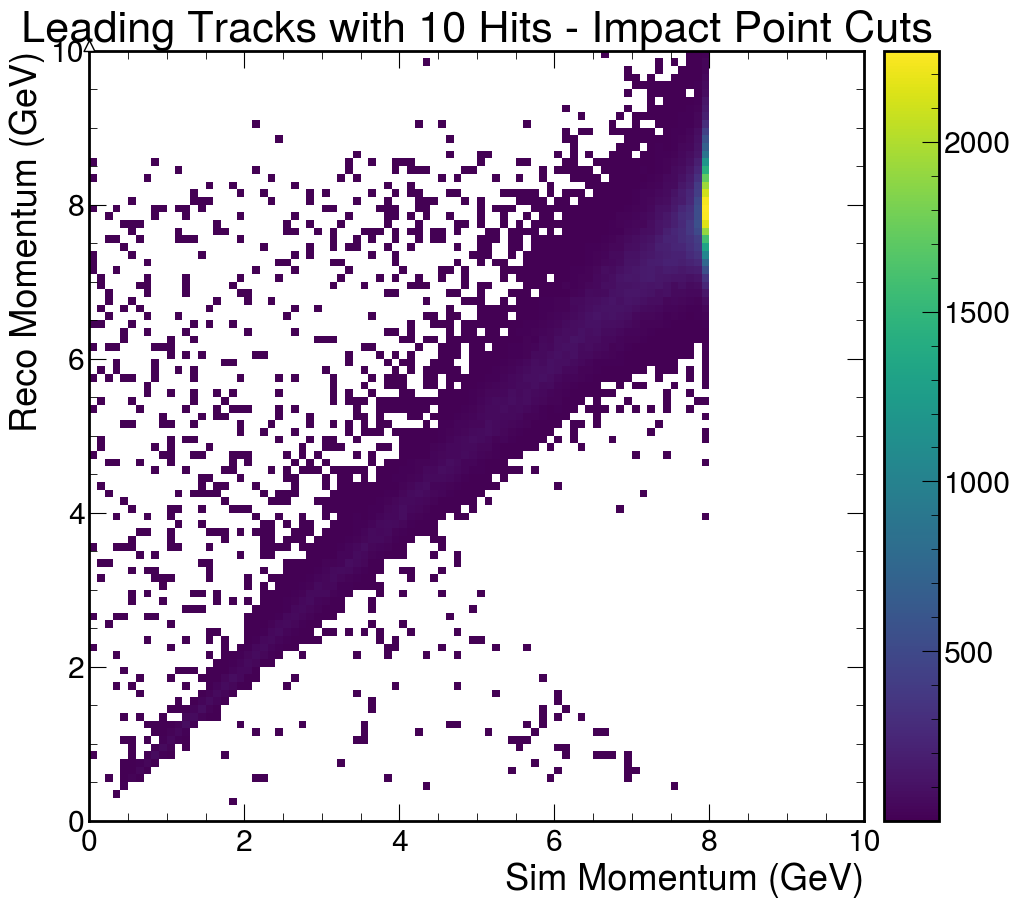

In [17]:
f['leadtrk_reco_vs_sim_momentum_nhits_10_impact_cuts'].to_hist().plot(cmin=1)
plt.title("Leading Tracks with 10 Hits - Impact Point Cuts")

plt.savefig("leadtrk_reco_vs_sim_momentum_nhits_10_impact_cuts.jpg")

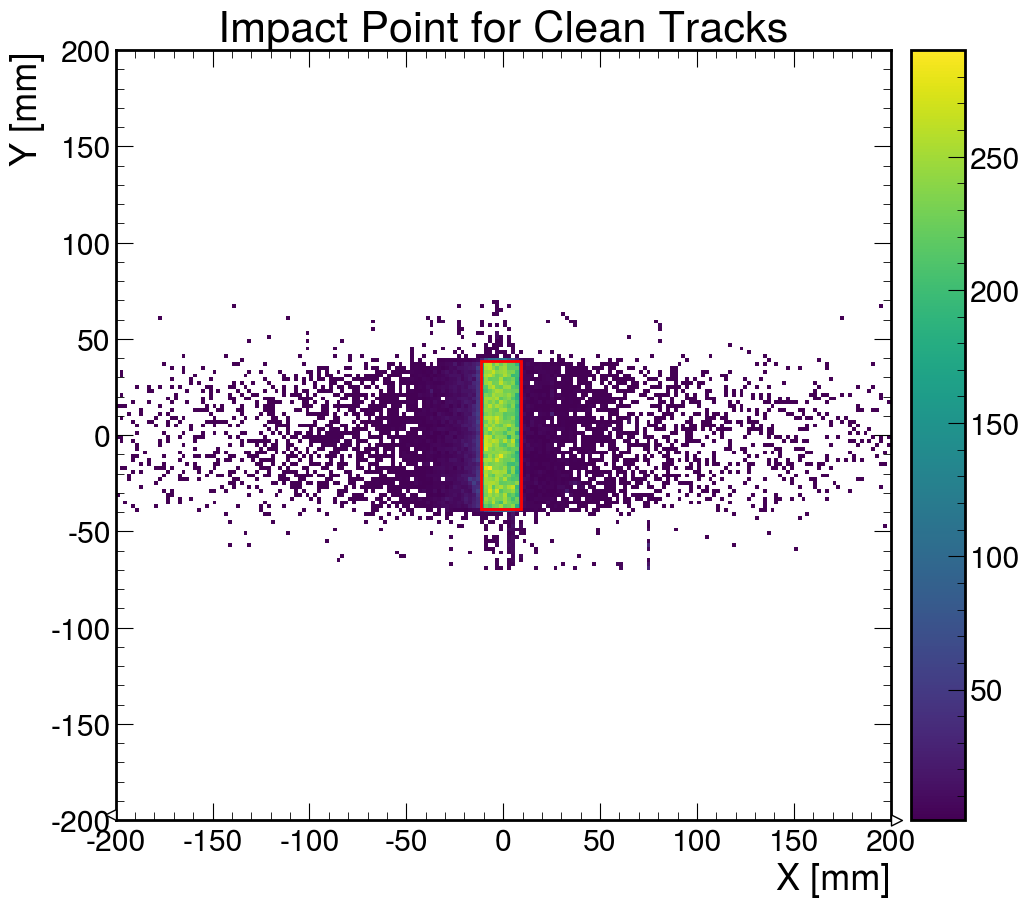

In [113]:
f['impact_point'].to_hist().plot(cmin=1)
ax = plt.gca()
plt.title("Impact Point for Clean Tracks")
rect = patches.Rectangle((-11.5, -38.5), 20.5, 77, linewidth=2, edgecolor='r', facecolor='none')
ax.add_patch(rect)
plt.savefig("impact_point_clean_tracks_BEAMSPOT.jpg")

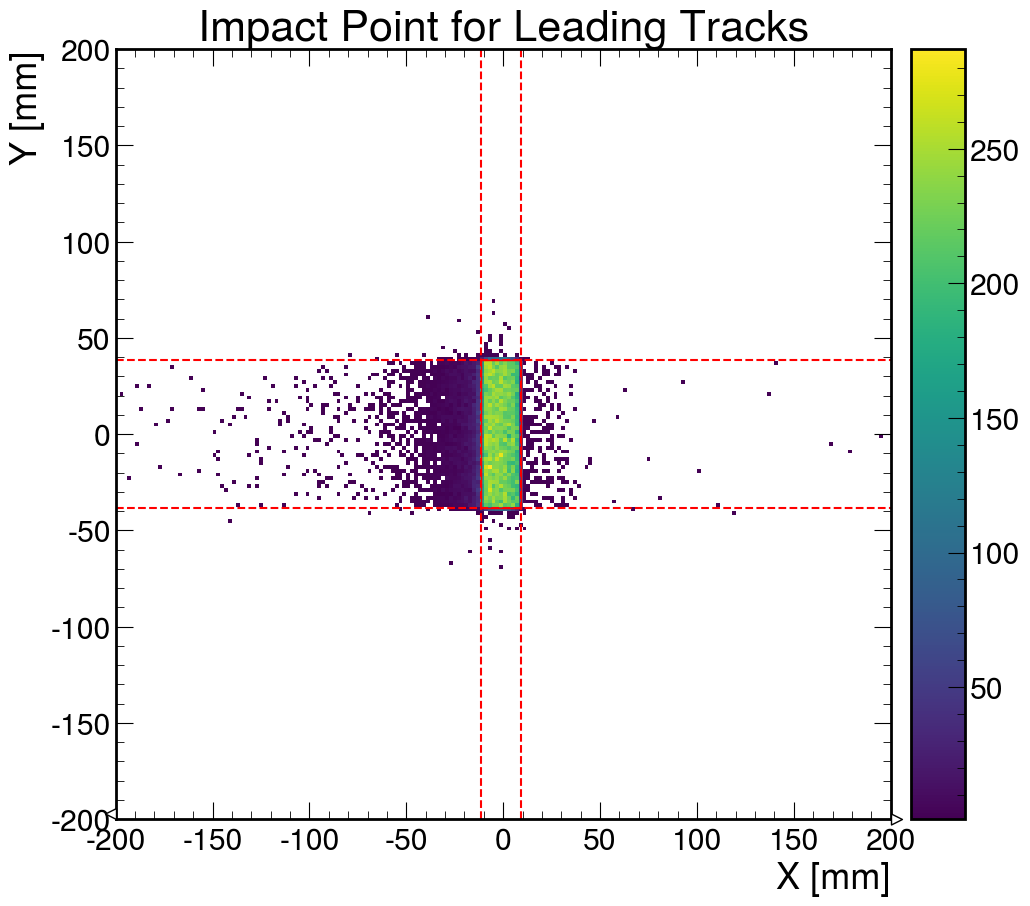

In [96]:
f['leadtrk_impact_point'].to_hist().plot(cmin=1)
ax = plt.gca()
plt.title("Impact Point for Leading Tracks")
#plt.axhline(-38.5, color = "r", linestyle='--')

#plt.axvline(-11.5, color = "r", linestyle='--')
#plt.axhline(38.5,color = "r", linestyle='--')
#plt.axvline(9, color = "r", linestyle='--')
rect = patches.Rectangle((-11.5, -38.5), 20.5, 77, linewidth=1, edgecolor='r', facecolor='none')
ax.add_patch(rect)
#plt.show()
#plt.savefig("leadtrk_tracks_impact_point.jpg")

ColormeshArtists(pcolormesh=<matplotlib.collections.QuadMesh object at 0x7f16aa95ad50>, cbar=<matplotlib.colorbar.Colorbar object at 0x7f16aa158e90>, text=[])

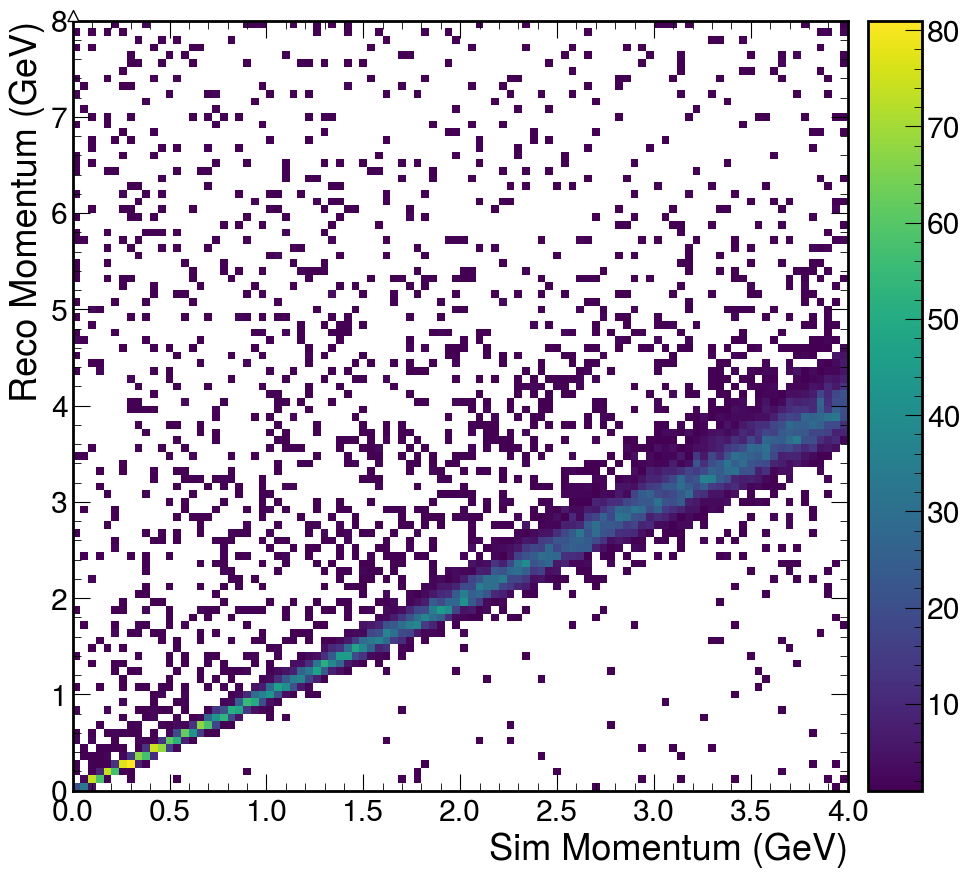

In [38]:
f['leadtrk_reco_vs_sim_momentum_under_4'].to_hist().plot(cmin=1)
#plt.title("Impact Point for Leading Tracks")

#plt.savefig("leadtrk_tracks_impact_point.jpg")